## Partie 1 : Préparation & Imports

In [2]:
import sys, os
import pandas as pd
import numpy as np

sys.path.append(os.path.abspath(".."))

import lib.video_processing as vp
import lib.extract_features as ef
import lib.run_ml_classification as cp
from lib.data_augmentation import augment_dataset
import lib.hyperparameter_tuning as ht_fast

# Paths
path_videos = r'C:\Users\SAWSAN\Downloads\PD\PD\videos'
dataset_identifier = "fis"

print("✅ Setup ready")

✅ Setup ready


## Partie 2 : Traitement des vidéos
Extraction des séries temporelles (landmarks → time series).

In [ ]:
#Define videos path
path_videos = r'C:\Users\SAWSAN\Downloads\PD\PD\videos'

dataset_identifier="fis"
import sys, os
sys.path.append(os.path.abspath(".."))

import lib.video_processing as vp
import lib.extract_features as ef
import lib.run_ml_classification as cp


#Extract baseline kinematic measures time series
vp.process_video(path_videos,dataset_identifier)

Found 234 videos
✅ MediaPipe ready!


Processing: 100%|██████████| 234/234 [1:34:09<00:00, 24.14s/it]


✅ COMPLETE! 33035 frames from 221 videos


## FEATURE EXTRACTION (AVANT SPLIT !)

In [2]:
ef.extract_all_features(dataset_identifier)


🔥 TSFRESH FEATURES


Feature Extraction: 100%|██████████| 20/20 [00:50<00:00,  2.52s/it]


📈 TSFresh extracted: (221, 3915)
📉 Selected features: (221, 894)
✅ Features after cleaning: (221, 741)
✅ Final selected features: (221, 50)
✅ TSFRESH DONE

🔥 CLASSICAL FEATURES
📊 Classical features: (221, 17)
✅ CLASSICAL DONE

🔥 FI + TSFRESH FEATURES


Feature Extraction: 100%|██████████| 20/20 [00:23<00:00,  1.18s/it]


📊 Extracted features: (221, 2349)
✅ Features after cleaning: (221, 53)
✅ FI + TSFRESH DONE


## Partie 3 : Split des données
Division stricte 70/15/15 avant toute augmentation.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

dataset_identifier = "fis"

# Charger labels
diag_file = f"../input_files/{dataset_identifier}_diagnostic.csv"
labels = pd.read_csv(diag_file, dtype={'UPDRS': int, 'ID': str})

# Vérification
labels = labels.drop_duplicates(subset=['ID'])

ids = labels['ID'].values
y = labels['UPDRS'].values

# ======================
# SPLIT 70 / 15 / 15
# ======================
train_ids, temp_ids, y_train, y_temp = train_test_split(
    ids,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

val_ids, test_ids, y_val, y_test = train_test_split(
    temp_ids,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(f"✅ Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

# ======================
# SAUVEGARDE
# ======================
pd.DataFrame({'ID': train_ids}).to_csv(f"../input_files/{dataset_identifier}_train_ids.csv", index=False)
pd.DataFrame({'ID': val_ids}).to_csv(f"../input_files/{dataset_identifier}_val_ids.csv", index=False)
pd.DataFrame({'ID': test_ids}).to_csv(f"../input_files/{dataset_identifier}_test_ids.csv", index=False)

print("💾 IDs sauvegardés (train / val / test)")

✅ Train: 163 | Val: 35 | Test: 36
💾 IDs sauvegardés (train / val / test)


## Partie 4 : Data Augmentation
Application uniquement sur Train pour éviter le data leakage.

In [ ]:
import pandas as pd
from lib.data_augmentation import DataAugmentor

dataset_identifier = "fis"

# ================================
# 📌 PARTIE 4 : AUGMENTATION TRAIN
# ================================

train_ids = pd.read_csv(f"../input_files/{dataset_identifier}_train_ids.csv")['ID'].tolist()

augmentor = DataAugmentor(dataset_identifier)
augmentor.load_original_data()

# Sécurité : intersection
common_ids = set(augmentor.original_data['ID']) \
    .intersection(set(augmentor.diagnostic['ID'])) \
    .intersection(set(train_ids))

augmentor.original_data = augmentor.original_data[augmentor.original_data['ID'].isin(common_ids)]
augmentor.diagnostic = augmentor.diagnostic[augmentor.diagnostic['ID'].isin(common_ids)]

augmentor.analyze_class_distribution()
augmentor.target_count = 100

augmentor.create_augmented_videos(n_augmentations=5)

train_ts_file, train_diag_file, _, _ = augmentor.save_balanced_dataset()

print(f"✅ Train Augmented sauvegardé :\n📈 {train_ts_file}\n🏷️ {train_diag_file}")


# ============================================
# 📌 PARTIE 5 : VALIDATION & TEST 
# ============================================

val_ids = pd.read_csv(f"../input_files/{dataset_identifier}_val_ids.csv")['ID'].tolist()
test_ids = pd.read_csv(f"../input_files/{dataset_identifier}_test_ids.csv")['ID'].tolist()

labels = pd.read_csv(f"../input_files/{dataset_identifier}_diagnostic.csv", dtype={'UPDRS': int, 'ID': str})
features = pd.read_csv(f"../output_files/{dataset_identifier}_data_time_series.csv", dtype={'ID': str})

# 🔥 IMPORTANT : supprimer doublons labels
labels = labels.drop_duplicates(subset=['ID'])

# ======================
# ✅ ALIGNEMENT AVANT FILTRAGE
# ======================
val_common_ids = set(val_ids).intersection(set(features['ID'])).intersection(set(labels['ID']))
test_common_ids = set(test_ids).intersection(set(features['ID'])).intersection(set(labels['ID']))

# Filtrage sécurisé
val_features = features[features['ID'].isin(val_common_ids)]
val_labels = labels[labels['ID'].isin(val_common_ids)]

test_features = features[features['ID'].isin(test_common_ids)]
test_labels = labels[labels['ID'].isin(test_common_ids)]

# ======================
# ✅ TRI ROBUSTE
# ======================
if 'frame' in val_features.columns:
    val_features = val_features.sort_values(by=['ID', 'frame'])
    test_features = test_features.sort_values(by=['ID', 'frame'])
else:
    print("⚠️ Colonne 'frame' introuvable → tri par ID")
    val_features = val_features.sort_values(by=['ID'])
    test_features = test_features.sort_values(by=['ID'])

# ======================
# ✅ VÉRIFICATION (sécurisée)
# ======================
print(f"🔍 Validation IDs: features={len(set(val_features['ID']))}, labels={len(set(val_labels['ID']))}")
print(f"🔍 Test IDs: features={len(set(test_features['ID']))}, labels={len(set(test_labels['ID']))}")

# (assert devient safe maintenant)
assert set(val_features['ID']) == set(val_labels['ID']), "❌ Mismatch Validation"
assert set(test_features['ID']) == set(test_labels['ID']), "❌ Mismatch Test"

# ======================
# 💾 SAUVEGARDE
# ======================
val_features.to_csv(f"../output_files/{dataset_identifier}_val_data_time_series.csv", index=False)
val_labels.to_csv(f"../input_files/{dataset_identifier}_val_diagnostic.csv", index=False)

test_features.to_csv(f"../output_files/{dataset_identifier}_test_data_time_series.csv", index=False)
test_labels.to_csv(f"../input_files/{dataset_identifier}_test_diagnostic.csv", index=False)
from lib import extract_features as ef

print("\n🚀 Extraction des features AUGMENTÉES...")

dataset_aug = "fis_balanced"

# Classical features
ef.extract_classical_features(dataset_aug)

# TSFRESH features
ef.extract_tsfresh_features(dataset_aug)

# FI + TSFRESH
ef.extract_fi_tsfresh_features(dataset_aug)

print("✅ Features augmentées générées !")

print("✅ Validation & Test sauvegardés séparément")
print(f"📈 Validation: {len(val_features)} lignes")
print(f"🧪 Test: {len(test_features)} lignes")

✅ 221 vidéos | Features: ['DISTANCE_ANG', 'SMOOTHED_AMPLITUDE', 'VELOCITY', 'ACCELERATION', 'FREQUENCY']

📊 DISTRIBUTION ORIGINALE:
-----------------------------------
  UPDRS 0:  48 ( 31.4%)
  UPDRS 1:  66 ( 43.1%)
  UPDRS 2:  23 ( 15.0%)
  UPDRS 3:  16 ( 10.5%)

🎯 Cible: 100 par classe

🔄 Équilibrage parfait → 100 vidéos/classe...
✅ 1/3 Originales conservées...
✅ 2/3 Augmentations ciblées...
  UPDRS 0: 48 → besoin 52
  UPDRS 0: FINAL 100 ✅
  UPDRS 1: 66 → besoin 34
  UPDRS 1: FINAL 100 ✅
  UPDRS 2: 23 → besoin 77
  UPDRS 2: FINAL 100 ✅
  UPDRS 3: 16 → besoin 84
  UPDRS 3: FINAL 100 ✅
✅ 3/3 Fusion finale...

📊 VÉRIFICATION ÉQUILIBRAGE:
  UPDRS 0: 100 ✅
  UPDRS 1: 100 ✅
  UPDRS 2: 100 ✅
  UPDRS 3: 100 ✅
🎉 TOTAL: 400 vidéos

✅ 4 FICHIERS COMPLÈTS:
   📈 Time series: fis_balanced_data_time_series.csv
   🏷️  Diagnostic:  fis_balanced_diagnostic.csv
   ⚡ FPS:          fis_balanced_fps_videos.csv
   📊 Frame rate:   fis_balanced_frame_rate_processed_videos.csv
✅ Train Augmented sauvegardé :
📈

Feature Extraction: 100%|██████████| 20/20 [01:25<00:00,  4.27s/it]


📈 TSFresh extracted: (400, 4698)
📉 Selected features: (400, 2169)
✅ Features after cleaning: (400, 1803)
✅ Final selected features: (400, 50)
✅ TSFRESH DONE

🔥 FI + TSFRESH FEATURES


Feature Extraction: 100%|██████████| 20/20 [00:41<00:00,  2.09s/it]


📊 Extracted features: (400, 2349)
✅ Features after cleaning: (400, 54)
✅ FI + TSFRESH DONE
✅ Features augmentées générées !
✅ Validation & Test sauvegardés séparément
📈 Validation: 5076 lignes
🧪 Test: 5086 lignes


## ENTRAÎNEMENT DU MODÈLE

## Partie 6 – Classification & Évaluation

________________________________


🎯 COMPLETE AI PIPELINE

🧬 STEP 1 → DATA AUGMENTATION
🎯 DATA AUGMENTATION fis
✅ 221 vidéos | Features: ['DISTANCE_ANG', 'SMOOTHED_AMPLITUDE', 'VELOCITY', 'ACCELERATION', 'FREQUENCY']

📊 DISTRIBUTION ORIGINALE:
-----------------------------------
  UPDRS 0:  68 ( 30.8%)
  UPDRS 1:  96 ( 43.4%)
  UPDRS 2:  34 ( 15.4%)
  UPDRS 3:  23 ( 10.4%)

🎯 Cible: 100 par classe

🔄 Équilibrage parfait → 100 vidéos/classe...
✅ 1/3 Originales conservées...
✅ 2/3 Augmentations ciblées...
  UPDRS 0: 68 → besoin 32
  UPDRS 0: FINAL 100 ✅
  UPDRS 1: 96 → besoin 4
  UPDRS 1: FINAL 100 ✅
  UPDRS 2: 34 → besoin 66
  UPDRS 2: FINAL 100 ✅
  UPDRS 3: 23 → besoin 77
  UPDRS 3: FINAL 100 ✅
✅ 3/3 Fusion finale...

📊 VÉRIFICATION ÉQUILIBRAGE:
  UPDRS 0: 100 ✅
  UPDRS 1: 100 ✅
  UPDRS 2: 100 ✅
  UPDRS 3: 100 ✅
🎉 TOTAL: 400 vidéos



✅ 4 FICHIERS COMPLÈTS:
   📈 Time series: fis_balanced_data_time_series.csv
   🏷️  Diagnostic:  fis_balanced_diagnostic.csv
   ⚡ FPS:          fis_balanced_fps_videos.csv
   📊 Frame rate:   fis_balanced_frame_rate_processed_videos.csv

📊 STEP 2 → DATASET ANALYSIS

📈 ORIGINAL DATASET : 234 vidéos
📈 AUGMENTED DATASET: 400 vidéos

📊 CLASS DISTRIBUTION
UPDRS 0 → Original:  71 | Augmented: 100
UPDRS 1 → Original:  99 | Augmented: 100
UPDRS 2 → Original:  38 | Augmented: 100
UPDRS 3 → Original:  26 | Augmented: 100

🔥 STEP 3 → FEATURE EXTRACTION

📌 ORIGINAL FEATURES

🔥 TSFRESH FEATURES


Feature Extraction: 100%|██████████| 20/20 [01:24<00:00,  4.22s/it]


📈 TSFresh extracted: (221, 3915)
📉 Selected features: (221, 894)
✅ Features after cleaning: (221, 741)
✅ Final selected features: (221, 50)
✅ TSFRESH DONE

🔥 CLASSICAL FEATURES


📊 Classical features: (221, 17)
✅ CLASSICAL DONE

🔥 FI + TSFRESH FEATURES


...

📊 Extracted features: (221, 2349)
✅ Features after cleaning: (221, 53)
✅ FI + TSFRESH DONE

📌 AUGMENTED FEATURES

🔥 TSFRESH FEATURES


Feature Extraction: 100%|██████████| 20/20 [02:13<00:00,  6.67s/it]


📈 TSFresh extracted: (400, 4698)
📉 Selected features: (400, 2021)
✅ Features after cleaning: (400, 1669)
✅ Final selected features: (400, 50)
✅ TSFRESH DONE

🔥 CLASSICAL FEATURES
📊 Classical features: (400, 17)
✅ CLASSICAL DONE

🔥 FI + TSFRESH FEATURES


Feature Extraction: 100%|██████████| 20/20 [00:42<00:00,  2.15s/it]


📊 Extracted features: (400, 2349)
✅ Features after cleaning: (400, 67)
✅ FI + TSFRESH DONE

🏆 STEP 4 → MODELS EVALUATION

🚀 FEATURE TYPE → CLASSICAL

✅ Train: (320, 16)
✅ Test : (80, 16)

------------------------------------------------------------
🤖 MODEL → LogisticRegression
------------------------------------------------------------
📊 Train Accuracy : 0.6781
📊 Test Accuracy  : 0.6625
📉 Train Loss     : 0.8087
📉 Test Loss      : 0.8066
⚠️ Overfitting    : 0.0156

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.71      0.75      0.73        20
           1       0.60      0.45      0.51        20
           2       0.50      0.60      0.55        20
           3       0.85      0.85      0.85        20

    accuracy                           0.66        80
   macro avg       0.67      0.66      0.66        80
weighted avg       0.67      0.66      0.66        80



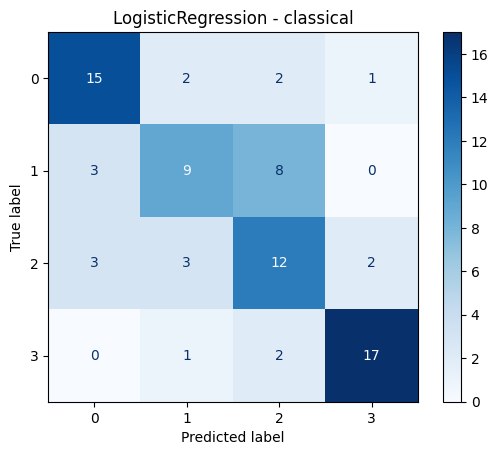


------------------------------------------------------------
🤖 MODEL → KNeighborsClassifier
------------------------------------------------------------
📊 Train Accuracy : 0.8000
📊 Test Accuracy  : 0.6250
📉 Train Loss     : 0.4903
📉 Test Loss      : 2.4088
⚠️ Overfitting    : 0.1750

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.60      0.75      0.67        20
           1       0.38      0.30      0.33        20
           2       0.63      0.60      0.62        20
           3       0.85      0.85      0.85        20

    accuracy                           0.62        80
   macro avg       0.61      0.62      0.62        80
weighted avg       0.61      0.62      0.62        80



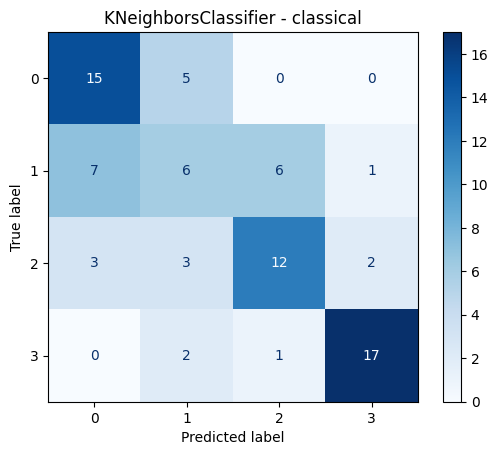


------------------------------------------------------------
🤖 MODEL → DecisionTreeClassifier
------------------------------------------------------------
📊 Train Accuracy : 0.9344
📊 Test Accuracy  : 0.6875
📉 Train Loss     : 0.1024
📉 Test Loss      : 9.0832
⚠️ Overfitting    : 0.2469

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.75      0.75      0.75        20
           1       0.50      0.40      0.44        20
           2       0.56      0.70      0.62        20
           3       0.95      0.90      0.92        20

    accuracy                           0.69        80
   macro avg       0.69      0.69      0.68        80
weighted avg       0.69      0.69      0.68        80



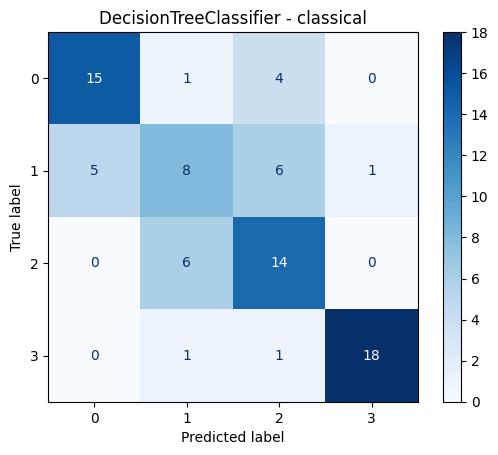


------------------------------------------------------------
🤖 MODEL → RandomForestClassifier
------------------------------------------------------------
📊 Train Accuracy : 0.9875
📊 Test Accuracy  : 0.7875
📉 Train Loss     : 0.2727
📉 Test Loss      : 0.6170
⚠️ Overfitting    : 0.2000

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.75      0.75      0.75        20
           1       0.67      0.60      0.63        20
           2       0.74      0.85      0.79        20
           3       1.00      0.95      0.97        20

    accuracy                           0.79        80
   macro avg       0.79      0.79      0.79        80
weighted avg       0.79      0.79      0.79        80



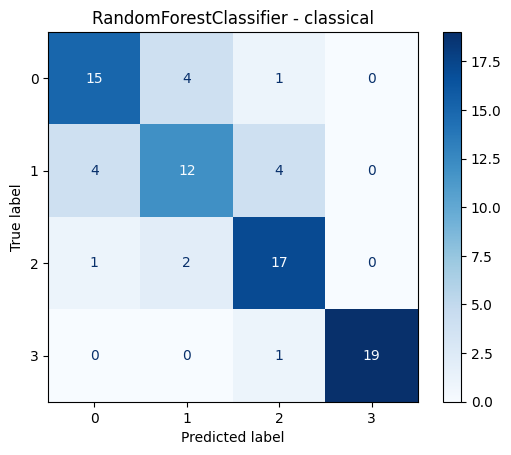


------------------------------------------------------------
🤖 MODEL → AdaBoostClassifier
------------------------------------------------------------
📊 Train Accuracy : 0.6125
📊 Test Accuracy  : 0.5750
📉 Train Loss     : 1.3204
📉 Test Loss      : 1.3269
⚠️ Overfitting    : 0.0375

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.55      0.90      0.68        20
           1       0.38      0.25      0.30        20
           2       0.42      0.40      0.41        20
           3       1.00      0.75      0.86        20

    accuracy                           0.57        80
   macro avg       0.59      0.57      0.56        80
weighted avg       0.59      0.57      0.56        80



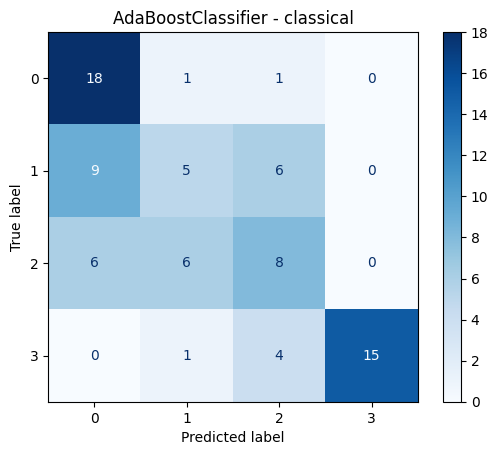


------------------------------------------------------------
🤖 MODEL → XGBClassifier
------------------------------------------------------------
📊 Train Accuracy : 1.0000
📊 Test Accuracy  : 0.8000
📉 Train Loss     : 0.0151
📉 Test Loss      : 0.6045
⚠️ Overfitting    : 0.2000

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.76      0.80      0.78        20
           1       0.68      0.65      0.67        20
           2       0.76      0.80      0.78        20
           3       1.00      0.95      0.97        20

    accuracy                           0.80        80
   macro avg       0.80      0.80      0.80        80
weighted avg       0.80      0.80      0.80        80



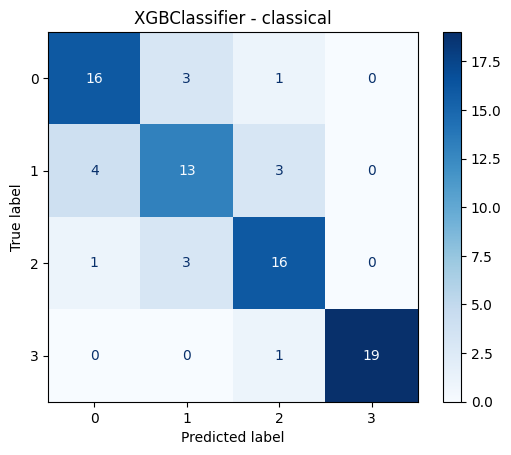


🚀 FEATURE TYPE → TSFRESH

✅ Train: (320, 50)
✅ Test : (80, 50)

------------------------------------------------------------
🤖 MODEL → LogisticRegression
------------------------------------------------------------
📊 Train Accuracy : 0.6750
📊 Test Accuracy  : 0.7875
📉 Train Loss     : 0.7365
📉 Test Loss      : 0.6446
⚠️ Overfitting    : -0.1125

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.93      0.70      0.80        20
           1       0.81      0.85      0.83        20
           2       0.61      0.85      0.71        20
           3       0.94      0.75      0.83        20

    accuracy                           0.79        80
   macro avg       0.82      0.79      0.79        80
weighted avg       0.82      0.79      0.79        80



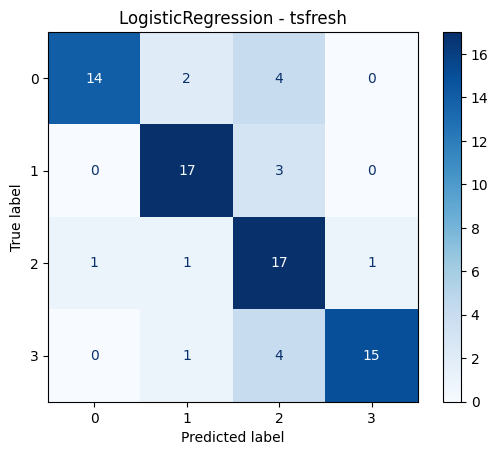


------------------------------------------------------------
🤖 MODEL → KNeighborsClassifier
------------------------------------------------------------
📊 Train Accuracy : 0.8469
📊 Test Accuracy  : 0.8000
📉 Train Loss     : 0.3275
📉 Test Loss      : 3.8285
⚠️ Overfitting    : 0.0469

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.74      0.85      0.79        20
           1       0.81      0.65      0.72        20
           2       0.77      0.85      0.81        20
           3       0.89      0.85      0.87        20

    accuracy                           0.80        80
   macro avg       0.80      0.80      0.80        80
weighted avg       0.80      0.80      0.80        80



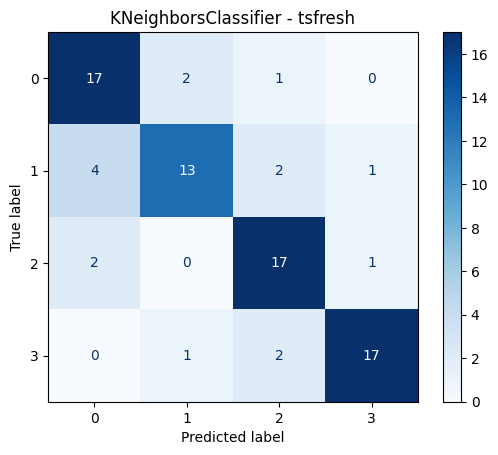


------------------------------------------------------------
🤖 MODEL → DecisionTreeClassifier
------------------------------------------------------------
📊 Train Accuracy : 0.9281
📊 Test Accuracy  : 0.7875
📉 Train Loss     : 0.1127
📉 Test Loss      : 7.2637
⚠️ Overfitting    : 0.1406

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.71      0.85      0.77        20
           1       0.75      0.60      0.67        20
           2       0.81      0.85      0.83        20
           3       0.89      0.85      0.87        20

    accuracy                           0.79        80
   macro avg       0.79      0.79      0.79        80
weighted avg       0.79      0.79      0.79        80



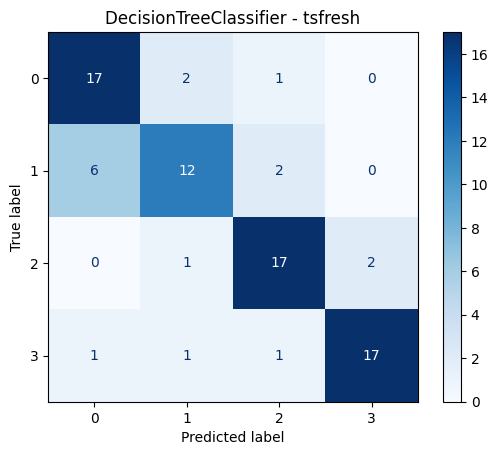


------------------------------------------------------------
🤖 MODEL → RandomForestClassifier
------------------------------------------------------------
📊 Train Accuracy : 0.9656
📊 Test Accuracy  : 0.8375
📉 Train Loss     : 0.1927
📉 Test Loss      : 0.4683
⚠️ Overfitting    : 0.1281

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.81      0.85      0.83        20
           1       0.79      0.75      0.77        20
           2       0.82      0.90      0.86        20
           3       0.94      0.85      0.89        20

    accuracy                           0.84        80
   macro avg       0.84      0.84      0.84        80
weighted avg       0.84      0.84      0.84        80



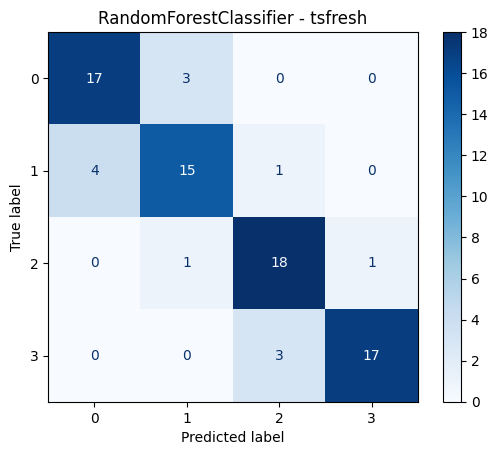


------------------------------------------------------------
🤖 MODEL → AdaBoostClassifier
------------------------------------------------------------
📊 Train Accuracy : 0.7562
📊 Test Accuracy  : 0.8375
📉 Train Loss     : 1.3076
📉 Test Loss      : 1.3104
⚠️ Overfitting    : -0.0813

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.63      0.95      0.76        20
           2       1.00      0.80      0.89        20
           3       1.00      0.80      0.89        20

    accuracy                           0.84        80
   macro avg       0.88      0.84      0.84        80
weighted avg       0.88      0.84      0.84        80



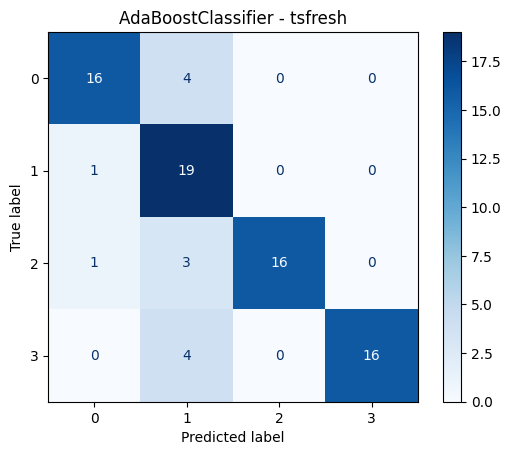


------------------------------------------------------------
🤖 MODEL → XGBClassifier
------------------------------------------------------------
📊 Train Accuracy : 1.0000
📊 Test Accuracy  : 0.7875
📉 Train Loss     : 0.0295
📉 Test Loss      : 0.7928
⚠️ Overfitting    : 0.2125

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.76      0.80      0.78        20
           1       0.68      0.65      0.67        20
           2       0.76      0.80      0.78        20
           3       0.95      0.90      0.92        20

    accuracy                           0.79        80
   macro avg       0.79      0.79      0.79        80
weighted avg       0.79      0.79      0.79        80



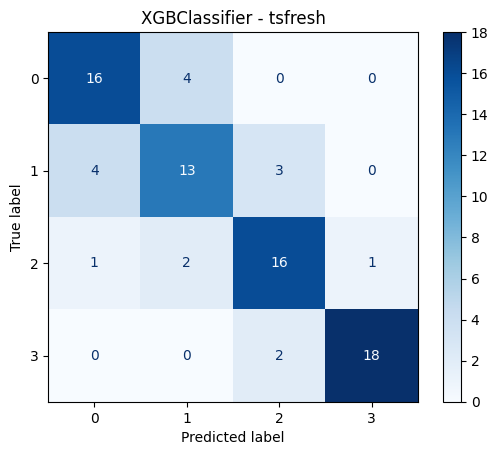


🚀 FEATURE TYPE → FI_TSFRESH

✅ Train: (320, 67)
✅ Test : (80, 67)

------------------------------------------------------------
🤖 MODEL → LogisticRegression
------------------------------------------------------------
📊 Train Accuracy : 0.5312
📊 Test Accuracy  : 0.4750
📉 Train Loss     : 1.0405
📉 Test Loss      : 1.1751
⚠️ Overfitting    : 0.0563

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.46      0.55      0.50        20
           1       0.31      0.20      0.24        20
           2       0.47      0.40      0.43        20
           3       0.58      0.75      0.65        20

    accuracy                           0.47        80
   macro avg       0.45      0.47      0.46        80
weighted avg       0.45      0.47      0.46        80



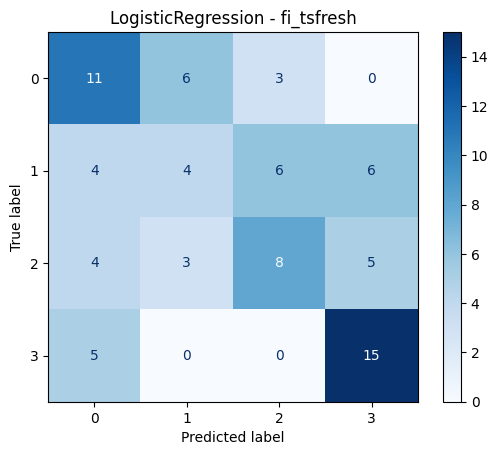


------------------------------------------------------------
🤖 MODEL → KNeighborsClassifier
------------------------------------------------------------
📊 Train Accuracy : 0.7000
📊 Test Accuracy  : 0.4875
📉 Train Loss     : 0.6076
📉 Test Loss      : 2.1028
⚠️ Overfitting    : 0.2125

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.41      0.65      0.50        20
           1       0.29      0.20      0.24        20
           2       0.62      0.50      0.56        20
           3       0.67      0.60      0.63        20

    accuracy                           0.49        80
   macro avg       0.50      0.49      0.48        80
weighted avg       0.50      0.49      0.48        80



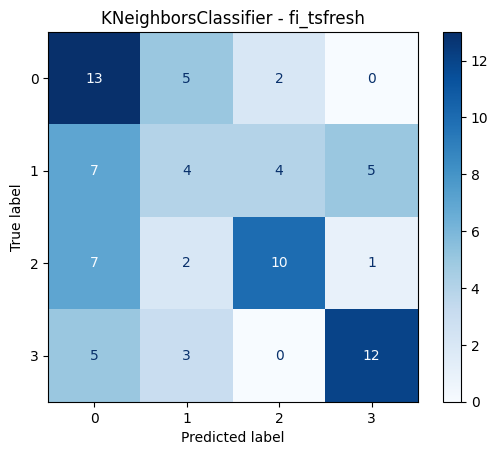


------------------------------------------------------------
🤖 MODEL → DecisionTreeClassifier
------------------------------------------------------------
📊 Train Accuracy : 0.9344
📊 Test Accuracy  : 0.6625
📉 Train Loss     : 0.0975
📉 Test Loss      : 9.5561
⚠️ Overfitting    : 0.2719

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.56      0.70      0.62        20
           1       0.53      0.40      0.46        20
           2       0.79      0.95      0.86        20
           3       0.75      0.60      0.67        20

    accuracy                           0.66        80
   macro avg       0.66      0.66      0.65        80
weighted avg       0.66      0.66      0.65        80



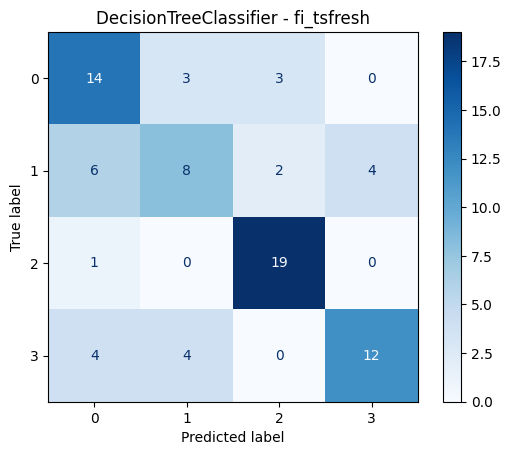


------------------------------------------------------------
🤖 MODEL → RandomForestClassifier
------------------------------------------------------------
📊 Train Accuracy : 0.9719
📊 Test Accuracy  : 0.7250
📉 Train Loss     : 0.3283
📉 Test Loss      : 0.7689
⚠️ Overfitting    : 0.2469

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.70      0.70      0.70        20
           1       0.46      0.30      0.36        20
           2       0.77      1.00      0.87        20
           3       0.86      0.90      0.88        20

    accuracy                           0.72        80
   macro avg       0.70      0.72      0.70        80
weighted avg       0.70      0.72      0.70        80



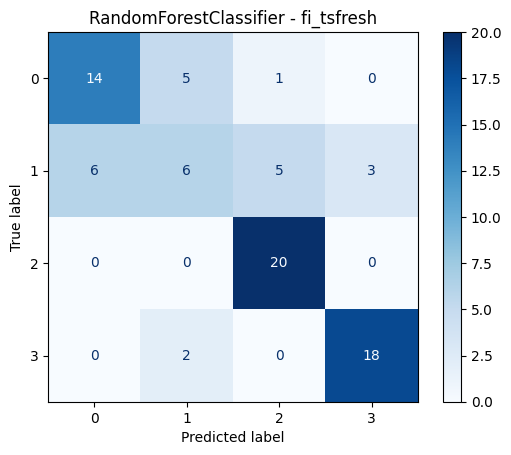


------------------------------------------------------------
🤖 MODEL → AdaBoostClassifier
------------------------------------------------------------
📊 Train Accuracy : 0.4938
📊 Test Accuracy  : 0.4750
📉 Train Loss     : 1.3350
📉 Test Loss      : 1.3422
⚠️ Overfitting    : 0.0188

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.41      0.65      0.50        20
           1       0.00      0.00      0.00        20
           2       0.39      0.55      0.46        20
           3       0.70      0.70      0.70        20

    accuracy                           0.47        80
   macro avg       0.37      0.48      0.41        80
weighted avg       0.37      0.47      0.41        80



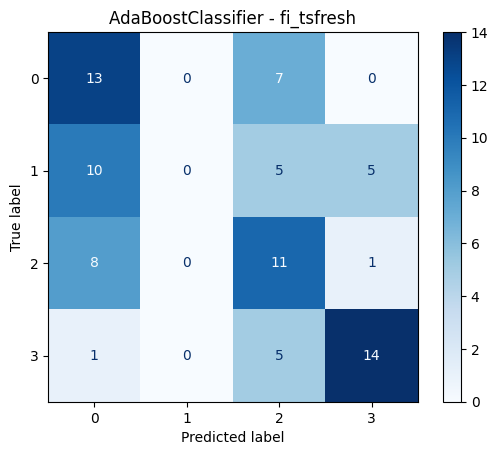


------------------------------------------------------------
🤖 MODEL → XGBClassifier
------------------------------------------------------------
📊 Train Accuracy : 1.0000
📊 Test Accuracy  : 0.7250
📉 Train Loss     : 0.0220
📉 Test Loss      : 0.8396
⚠️ Overfitting    : 0.2750

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.65      0.65      0.65        20
           1       0.50      0.40      0.44        20
           2       0.79      0.95      0.86        20
           3       0.90      0.90      0.90        20

    accuracy                           0.72        80
   macro avg       0.71      0.72      0.71        80
weighted avg       0.71      0.72      0.71        80



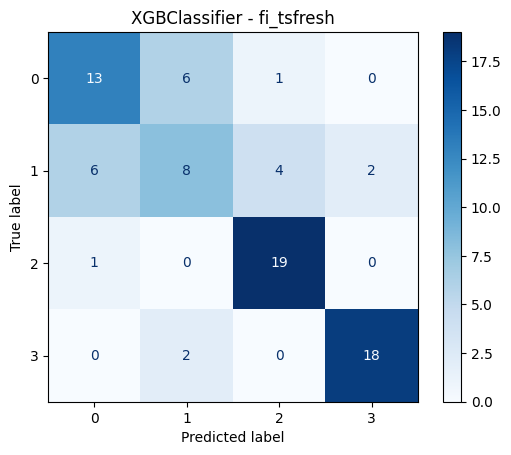


🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
🏆 BEST FINAL MODEL
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆

✅ Feature Type : tsfresh
✅ Model        : KNeighborsClassifier

📊 Train Accuracy : 0.8469
📊 Test Accuracy  : 0.8000

📈 Train F1 : 0.8458
📈 Test F1  : 0.7986

📉 Train Loss : 0.3275
📉 Test Loss  : 3.8285

⚠️ Overfitting : 0.0469

📊 TOP 5 MODELS (by score)
Feature_Type                  Model Test_Accuracy Train_Accuracy Overfitting Test_F1  Score
     tsfresh   KNeighborsClassifier        0.8000         0.8469      0.0469  0.7986 0.8000
     tsfresh RandomForestClassifier        0.8375         0.9656      0.1281  0.8376 0.7734
     tsfresh DecisionTreeClassifier        0.7875         0.9281      0.1406  0.7851 0.7172
     tsfresh     AdaBoostClassifier        0.8375         0.7562     -0.0813  0.8450 0.7062
   classical     LogisticRegression        0.6625         0.6781      0.0156  0.6604 0.6625

🔄 CROSS-VALIDATION VERIFICATION

📊 Cross-validation accuracy scores: [0.8375 0.7625 0.7875 0.7    0.775 ]
📊 Mean CV accu

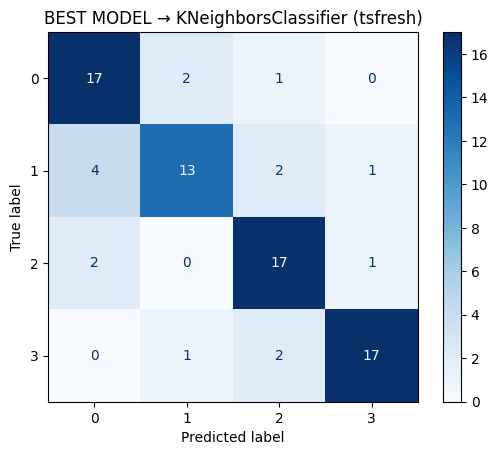


💾 Best model and scaler saved

📈 GENERATING LEARNING CURVES...


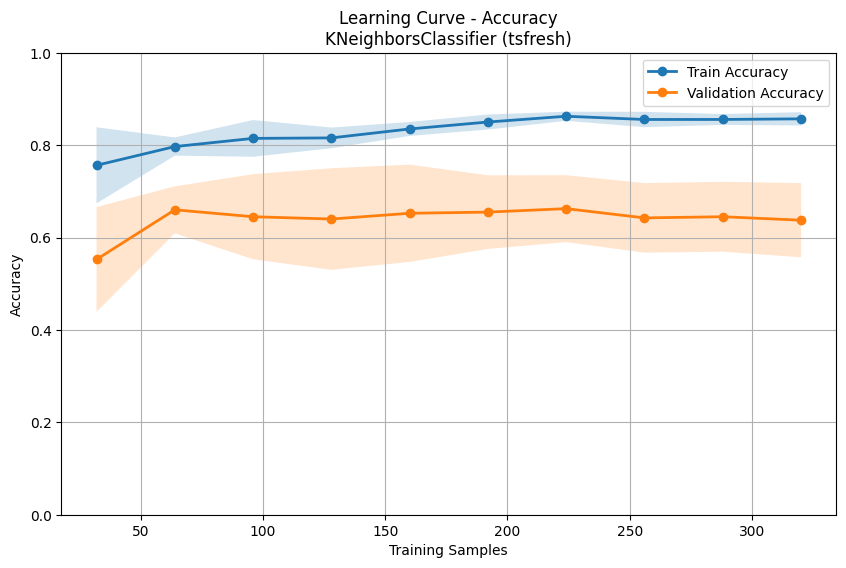

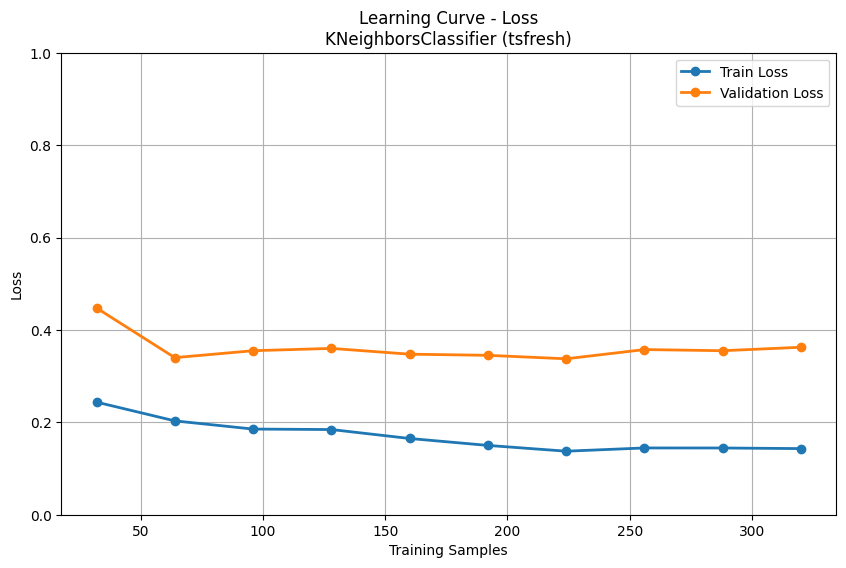

💾 Results CSV saved

✅ PIPELINE FINISHED SUCCESSFULLY


In [11]:
# =========================================================
# AUGMENTATION + FEATURES + CLASSIFICATION
# =========================================================

import sys
import os
import random
import joblib

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (

    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    log_loss

)

from sklearn.model_selection import (

    train_test_split,
    learning_curve,
    cross_val_score,
    StratifiedKFold

)

# =========================================================
# IMPORT PROJECT LIBRARIES
# =========================================================

sys.path.append(os.path.abspath(".."))

import lib.ml_models as m2t
import lib.extract_features as ef

from lib.data_augmentation import augment_dataset

# =========================================================
# RANDOM SEED
# =========================================================

np.random.seed(42)
random.seed(42)

# =========================================================
# DATASET
# =========================================================

dataset_identifier = "fis"

# =========================================================
# START
# =========================================================

print("\n🎯 COMPLETE AI PIPELINE")
print("="*80)

# =========================================================
# 1. DATA AUGMENTATION
# =========================================================

print("\n🧬 STEP 1 → DATA AUGMENTATION")
print("="*80)

augment_dataset(
    dataset_identifier,
    n_augmentations=5
)

# =========================================================
# 2. DATASET ANALYSIS
# =========================================================

print("\n📊 STEP 2 → DATASET ANALYSIS")
print("="*80)

orig_diag = pd.read_csv(
    f"../input_files/{dataset_identifier}_diagnostic.csv"
)

aug_diag = pd.read_csv(
    f"../input_files/{dataset_identifier}_balanced_diagnostic.csv"
)

print(f"\n📈 ORIGINAL DATASET : {len(orig_diag)} vidéos")
print(f"📈 AUGMENTED DATASET: {len(aug_diag)} vidéos")

print("\n📊 CLASS DISTRIBUTION")

for i in range(4):

    orig_count = orig_diag['UPDRS'].value_counts().get(i,0)
    aug_count = aug_diag['UPDRS'].value_counts().get(i,0)

    print(
        f"UPDRS {i} → "
        f"Original: {orig_count:3d} | "
        f"Augmented: {aug_count:3d}"
    )

# =========================================================
# 3. FEATURE EXTRACTION
# =========================================================

print("\n🔥 STEP 3 → FEATURE EXTRACTION")
print("="*80)

print("\n📌 ORIGINAL FEATURES")
ef.extract_all_features(dataset_identifier)

print("\n📌 AUGMENTED FEATURES")
ef.extract_all_features(f"{dataset_identifier}_balanced")

# =========================================================
# 4. MODEL EVALUATION
# =========================================================

print("\n🏆 STEP 4 → MODELS EVALUATION")
print("="*80)

feature_types = [

    "classical",
    "tsfresh",
    "fi_tsfresh"

]

all_results = []

# =========================================================
# LOOP FEATURE TYPES
# =========================================================

for ft in feature_types:

    print("\n" + "="*80)
    print(f"🚀 FEATURE TYPE → {ft.upper()}")
    print("="*80)

    # =====================================================
    # LOAD LABELS
    # =====================================================

    diag_file = (
        f"../input_files/"
        f"{dataset_identifier}_balanced_diagnostic.csv"
    )

    y_diagnostic = pd.read_csv(
        diag_file,
        dtype={
            'UPDRS': int,
            "ID": str
        }
    )

    y_diagnostic = (
        y_diagnostic
        .sort_values(by=['ID'])
        .drop_duplicates()
        .reset_index(drop=True)
    )

    # =====================================================
    # LOAD FEATURES
    # =====================================================

    features_file = (
        f"../output_files/"
        f"{dataset_identifier}_balanced_{ft}_features.csv"
    )

    features = pd.read_csv(features_file)

    if 'Unnamed: 0' in features.columns:

        features = features.rename(
            columns={"Unnamed: 0": "ID"}
        )

    # =====================================================
    # ALIGN IDS
    # =====================================================

    common_ids = np.intersect1d(
        features['ID'].values,
        y_diagnostic['ID'].values
    )

    features = features[
        features['ID'].isin(common_ids)
    ]

    y_diagnostic = y_diagnostic[
        y_diagnostic['ID'].isin(common_ids)
    ]

    # =====================================================
    # X / y
    # =====================================================

    X = features.drop(columns=['ID'])

    X = (
        X
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    scaler = StandardScaler()

    X = scaler.fit_transform(X)

    y = (
        y_diagnostic
        .set_index('ID')
        .loc[features.set_index('ID').index]['UPDRS']
        .values
    )

    # =====================================================
    # SPLIT
    # =====================================================

    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,

        test_size=0.2,

        stratify=y,

        random_state=42

    )

    print(f"\n✅ Train: {X_train.shape}")
    print(f"✅ Test : {X_test.shape}")

    # =====================================================
    # LOOP MODELS
    # =====================================================

    for model_name, model_class in m2t.models.items():

        print("\n" + "-"*60)
        print(f"🤖 MODEL → {model_name}")
        print("-"*60)

        try:

            params = m2t.fast_model_params.get(
                model_class,
                {}
            ).copy()

            if "default_acc" in params:
                params.pop("default_acc")

            if (
                model_name != "KNeighborsClassifier"
                and "random_state" in model_class().get_params()
            ):
                params['random_state'] = 42

            # =================================================
            # TRAIN MODEL
            # =================================================

            model = model_class(**params)

            model.fit(X_train, y_train)

            # =================================================
            # PREDICTIONS
            # =================================================

            y_pred_train = model.predict(X_train)
            y_pred_test = model.predict(X_test)

            # =================================================
            # PROBABILITIES
            # =================================================

            if hasattr(model, "predict_proba"):

                y_prob_train = model.predict_proba(X_train)
                y_prob_test = model.predict_proba(X_test)

                train_loss = log_loss(
                    y_train,
                    y_prob_train
                )

                test_loss = log_loss(
                    y_test,
                    y_prob_test
                )

            else:

                train_loss = np.nan
                test_loss = np.nan

            # =================================================
            # METRICS
            # =================================================

            train_acc = accuracy_score(
                y_train,
                y_pred_train
            )

            test_acc = accuracy_score(
                y_test,
                y_pred_test
            )

            train_f1 = f1_score(
                y_train,
                y_pred_train,
                average='weighted'
            )

            test_f1 = f1_score(
                y_test,
                y_pred_test,
                average='weighted'
            )

            overfitting = train_acc - test_acc

            # =================================================
            # PRINT RESULTS
            # =================================================

            print(f"📊 Train Accuracy : {train_acc:.4f}")
            print(f"📊 Test Accuracy  : {test_acc:.4f}")

            print(f"📉 Train Loss     : {train_loss:.4f}")
            print(f"📉 Test Loss      : {test_loss:.4f}")

            print(f"⚠️ Overfitting    : {overfitting:.4f}")

            # =================================================
            # CLASSIFICATION REPORT
            # =================================================

            print("\n📋 CLASSIFICATION REPORT\n")

            print(
                classification_report(
                    y_test,
                    y_pred_test,
                    zero_division=0
                )
            )

            # =================================================
            # CONFUSION MATRIX
            # =================================================

            cm = confusion_matrix(
                y_test,
                y_pred_test
            )

            disp = ConfusionMatrixDisplay(
                confusion_matrix=cm
            )

            disp.plot(cmap='Blues')

            plt.title(
                f"{model_name} - {ft}"
            )

            plt.show()

            # =================================================
            # SAVE RESULTS
            # =================================================

            all_results.append({

                "Feature_Type": ft,
                "Model": model_name,

                "Train_Accuracy": train_acc,
                "Test_Accuracy": test_acc,

                "Train_F1": train_f1,
                "Test_F1": test_f1,

                "Train_Loss": train_loss,
                "Test_Loss": test_loss,

                "Overfitting": overfitting,

                "Model_Object": model,
                "Scaler": scaler,

                "X": X,
                "y": y,

                "X_train": X_train,
                "X_test": X_test,
                "y_train": y_train,
                "y_test": y_test,
                "y_pred": y_pred_test

            })

        except Exception as e:

            print(f"❌ ERROR → {model_name}")
            print(e)

# =========================================================
# BEST MODEL SELECTION WITH PROPER CRITERIA
# =========================================================

def select_best_model(results_df):
    """
    Select the best model based on:
    1. Test accuracy (primary)
    2. Generalization gap penalty (smaller = better)
    3. Reject models with test > train (unless small)
    4. F1-score tiebreaker
    """
    
    # Make a copy to avoid modifying original
    df = results_df.copy()
    
    # =========================================================
    # FILTER 1: Remove clearly problematic models
    # =========================================================
    
    # Reject models with overfitting > 15% (train much higher than test)
    df = df[df['Overfitting'] <= 0.15]
    
    # Flag suspicious models (test > train by more than 3%)
    df['Suspicious'] = df['Overfitting'] < -0.03
    
    # Separate suspicious models (we'll keep them but penalize)
    suspicious_df = df[df['Suspicious']].copy()
    good_df = df[~df['Suspicious']].copy()
    
    # =========================================================
    # SCORING FUNCTION
    # =========================================================
    
    def compute_score(row):
        """
        Score = Test_Accuracy - penalty
        Penalty: 
        - Overfitting > 5%: penalty = Overfitting * 0.5
        - Negative gap (test > train): penalty = abs(Overfitting) * 1.0
        """
        test_acc = row['Test_Accuracy']
        overfitting = row['Overfitting']
        
        if overfitting > 0.05:
            # Overfitting penalty
            penalty = overfitting * 0.5
        elif overfitting < -0.03:
            # Suspicious (test better than train) penalty
            penalty = abs(overfitting) * 1.0
        else:
            # Ideal range (-3% to +5%)
            penalty = 0
        
        return test_acc - penalty
    
    # Apply scoring
    if len(good_df) > 0:
        good_df['Score'] = good_df.apply(compute_score, axis=1)
    
    if len(suspicious_df) > 0:
        suspicious_df['Score'] = suspicious_df.apply(compute_score, axis=1)
        # Reduce score further for suspicious models
        suspicious_df['Score'] = suspicious_df['Score'] - 0.05
    
    # Combine back
    if len(good_df) > 0 and len(suspicious_df) > 0:
        final_df = pd.concat([good_df, suspicious_df], ignore_index=True)
    elif len(good_df) > 0:
        final_df = good_df
    elif len(suspicious_df) > 0:
        final_df = suspicious_df
    else:
        final_df = df
    
    # Sort by score descending, then F1, then overfitting
    final_df = final_df.sort_values(
        by=['Score', 'Test_F1', 'Overfitting'],
        ascending=[False, False, True]
    )
    
    return final_df

# =========================================================
# APPLY SELECTION
# =========================================================

results_df = pd.DataFrame(all_results)

# Apply intelligent selection
results_df = select_best_model(results_df)

# If no models passed filtering, fallback to original
if len(results_df) == 0:
    print("\n⚠️ No model passed filters. Using fallback selection...")
    results_df = pd.DataFrame(all_results)
    results_df = results_df.sort_values(
        by=['Test_Accuracy', 'Test_F1', 'Overfitting'],
        ascending=[False, False, True]
    )

# =========================================================
# BEST MODEL
# =========================================================

best = results_df.iloc[0]

print("\n" + "🏆"*25)
print("🏆 BEST FINAL MODEL")
print("🏆"*25)

print(f"\n✅ Feature Type : {best['Feature_Type']}")
print(f"✅ Model        : {best['Model']}")

print(f"\n📊 Train Accuracy : {best['Train_Accuracy']:.4f}")
print(f"📊 Test Accuracy  : {best['Test_Accuracy']:.4f}")

print(f"\n📈 Train F1 : {best['Train_F1']:.4f}")
print(f"📈 Test F1  : {best['Test_F1']:.4f}")

print(f"\n📉 Train Loss : {best['Train_Loss']:.4f}")
print(f"📉 Test Loss  : {best['Test_Loss']:.4f}")

print(f"\n⚠️ Overfitting : {best['Overfitting']:.4f}")

# Warning for suspicious models
if best['Overfitting'] < -0.03:
    print("\n⚠️⚠️⚠️ WARNING ⚠️⚠️⚠️")
    print("Test accuracy > Train accuracy by more than 3%")
    print("This model may be unreliable. Consider:")
    print("1. Checking test set distribution")
    print("2. Running cross-validation")
    print("3. Testing on a different random split")

# =========================================================
# DISPLAY TOP 5 MODELS
# =========================================================

print("\n" + "="*80)
print("📊 TOP 5 MODELS (by score)")
print("="*80)

if 'Score' in results_df.columns:
    top_models = results_df.head(5)[
        ['Feature_Type', 'Model', 'Test_Accuracy', 'Train_Accuracy', 
         'Overfitting', 'Test_F1', 'Score']
    ].copy()
    
    top_models['Overfitting'] = top_models['Overfitting'].map(lambda x: f"{x:.4f}")
    top_models['Test_Accuracy'] = top_models['Test_Accuracy'].map(lambda x: f"{x:.4f}")
    top_models['Train_Accuracy'] = top_models['Train_Accuracy'].map(lambda x: f"{x:.4f}")
    top_models['Test_F1'] = top_models['Test_F1'].map(lambda x: f"{x:.4f}")
    top_models['Score'] = top_models['Score'].map(lambda x: f"{x:.4f}")
    
    print(top_models.to_string(index=False))

# =========================================================
# VALIDATION CHECK: CROSS-VALIDATION FOR BEST MODEL
# =========================================================

print("\n" + "="*80)
print("🔄 CROSS-VALIDATION VERIFICATION")
print("="*80)

best_model_obj = best['Model_Object']
X_best_all = best['X']
y_best_all = best['y']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    best_model_obj, 
    X_best_all, 
    y_best_all, 
    cv=cv, 
    scoring='accuracy'
)

print(f"\n📊 Cross-validation accuracy scores: {cv_scores}")
print(f"📊 Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"📊 Single test accuracy: {best['Test_Accuracy']:.4f}")

# Consistency check
if abs(cv_scores.mean() - best['Test_Accuracy']) > 0.05:
    print("\n⚠️ WARNING: Large difference between CV and test accuracy!")
    print("   The test split may not be representative.")
    print("   Consider using the CV mean as your reported accuracy.")

# =========================================================
# FINAL REPORT
# =========================================================

print("\n📋 FINAL CLASSIFICATION REPORT\n")

print(
    classification_report(
        best['y_test'],
        best['y_pred'],
        zero_division=0
    )
)

# =========================================================
# FINAL CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    best['y_test'],
    best['y_pred']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap='Blues')

plt.title(
    f"BEST MODEL → "
    f"{best['Model']} "
    f"({best['Feature_Type']})"
)

plt.show()

# =========================================================
# SAVE BEST MODEL AND SCALER
# =========================================================

joblib.dump(

    best['Model_Object'],
    f"../result_files/best_final_model.pkl"

)

joblib.dump(

    best['Scaler'],
    f"../result_files/best_scaler.pkl"

)

print("\n💾 Best model and scaler saved")

# =========================================================
# 📈 LEARNING CURVES
# =========================================================

print("\n📈 GENERATING LEARNING CURVES...")

best_model = best['Model_Object']
X_best = best['X']
y_best = best['y']

# =========================================================
# LEARNING CURVE
# =========================================================

train_sizes, train_scores, test_scores = learning_curve(

    estimator=best_model,

    X=X_best,
    y=y_best,

    cv=5,

    scoring='accuracy',

    train_sizes=np.linspace(0.1, 1.0, 10),

    shuffle=True,

    random_state=42,

    n_jobs=-1

)

# =========================================================
# MEAN SCORES
# =========================================================

train_acc_mean = np.mean(train_scores, axis=1)
test_acc_mean = np.mean(test_scores, axis=1)

train_acc_std = np.std(train_scores, axis=1)
test_acc_std = np.std(test_scores, axis=1)

# =========================================================
# LOSS
# =========================================================

train_loss_curve = 1 - train_acc_mean
test_loss_curve = 1 - test_acc_mean

# =========================================================
# ACCURACY CURVE
# =========================================================

plt.figure(figsize=(10,6))

plt.plot(
    train_sizes,
    train_acc_mean,
    marker='o',
    linewidth=2,
    label='Train Accuracy'
)

plt.plot(
    train_sizes,
    test_acc_mean,
    marker='o',
    linewidth=2,
    label='Validation Accuracy'
)

plt.fill_between(
    train_sizes,
    train_acc_mean - train_acc_std,
    train_acc_mean + train_acc_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    test_acc_mean - test_acc_std,
    test_acc_mean + test_acc_std,
    alpha=0.2
)

plt.title(
    f"Learning Curve - Accuracy\n"
    f"{best['Model']} ({best['Feature_Type']})"
)

plt.xlabel("Training Samples")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.legend()
plt.grid(True)

plt.show()

# =========================================================
# LOSS CURVE
# =========================================================

plt.figure(figsize=(10,6))

plt.plot(
    train_sizes,
    train_loss_curve,
    marker='o',
    linewidth=2,
    label='Train Loss'
)

plt.plot(
    train_sizes,
    test_loss_curve,
    marker='o',
    linewidth=2,
    label='Validation Loss'
)

plt.title(
    f"Learning Curve - Loss\n"
    f"{best['Model']} ({best['Feature_Type']})"
)

plt.xlabel("Training Samples")
plt.ylabel("Loss")

plt.ylim(0, 1)

plt.legend()
plt.grid(True)

plt.show()

# =========================================================
# SAVE CSV RESULTS
# =========================================================

# Remove non-serializable columns before saving
columns_to_drop = ['Model_Object', 'Scaler', 'X', 'y', 'X_train', 'X_test', 'y_train', 'y_test', 'y_pred']
columns_to_drop = [col for col in columns_to_drop if col in results_df.columns]

results_df.drop(
    columns=columns_to_drop
).to_csv(
    "../result_files/final_best_models_comparison.csv",
    index=False
)

print("💾 Results CSV saved")

print("\n✅ PIPELINE FINISHED SUCCESSFULLY")


🎯 COMPLETE PIPELINE

🧬 STEP 1 → DATA AUGMENTATION
🎯 DATA AUGMENTATION fis
✅ 221 vidéos | Features: ['DISTANCE_ANG', 'SMOOTHED_AMPLITUDE', 'VELOCITY', 'ACCELERATION', 'FREQUENCY']

📊 DISTRIBUTION ORIGINALE:
-----------------------------------
  UPDRS 0:  68 ( 30.8%)
  UPDRS 1:  96 ( 43.4%)
  UPDRS 2:  34 ( 15.4%)
  UPDRS 3:  23 ( 10.4%)

🎯 Cible: 100 par classe

🔄 Équilibrage parfait → 100 vidéos/classe...
✅ 1/3 Originales conservées...
✅ 2/3 Augmentations ciblées...
  UPDRS 0: 68 → besoin 32
  UPDRS 0: FINAL 100 ✅
  UPDRS 1: 96 → besoin 4
  UPDRS 1: FINAL 100 ✅
  UPDRS 2: 34 → besoin 66
  UPDRS 2: FINAL 100 ✅
  UPDRS 3: 23 → besoin 77
  UPDRS 3: FINAL 100 ✅
✅ 3/3 Fusion finale...

📊 VÉRIFICATION ÉQUILIBRAGE:
  UPDRS 0: 100 ✅
  UPDRS 1: 100 ✅
  UPDRS 2: 100 ✅
  UPDRS 3: 100 ✅
🎉 TOTAL: 400 vidéos



✅ 4 FICHIERS COMPLÈTS:
   📈 Time series: fis_balanced_data_time_series.csv
   🏷️  Diagnostic:  fis_balanced_diagnostic.csv
   ⚡ FPS:          fis_balanced_fps_videos.csv
   📊 Frame rate:   fis_balanced_frame_rate_processed_videos.csv

🔥 STEP 2 → FEATURE EXTRACTION

🔥 TSFRESH FEATURES


Feature Extraction: 100%|██████████| 20/20 [00:42<00:00,  2.14s/it]


📈 TSFresh extracted: (221, 3915)
📉 Selected features: (221, 894)
✅ Features after cleaning: (221, 741)
✅ Final selected features: (221, 50)
✅ TSFRESH DONE

🔥 CLASSICAL FEATURES
📊 Classical features: (221, 17)
✅ CLASSICAL DONE

🔥 FI + TSFRESH FEATURES


Feature Extraction: 100%|██████████| 20/20 [00:20<00:00,  1.03s/it]


...

✅ Features after cleaning: (221, 53)
✅ FI + TSFRESH DONE

🔥 TSFRESH FEATURES


Feature Extraction: 100%|██████████| 20/20 [01:42<00:00,  5.12s/it]


📈 TSFresh extracted: (400, 4698)
📉 Selected features: (400, 2021)
✅ Features after cleaning: (400, 1669)
✅ Final selected features: (400, 50)
✅ TSFRESH DONE

🔥 CLASSICAL FEATURES
📊 Classical features: (400, 17)
✅ CLASSICAL DONE

🔥 FI + TSFRESH FEATURES


Feature Extraction: 100%|██████████| 20/20 [00:38<00:00,  1.90s/it]


📊 Extracted features: (400, 2349)
✅ Features after cleaning: (400, 67)
✅ FI + TSFRESH DONE

🧪 EVALUATION → CLASSICAL
✅ Features after filtering: 8

✅ Train shape : (176, 8)
✅ Test shape  : (45, 8)

----------------------------------------------------------------------
🤖 MODEL → LogisticRegression
----------------------------------------------------------------------
✅ Best Params: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 2000, 'class_weight': None, 'C': np.float64(10.0)}
✅ CV Score   : 0.5589

📊 Train Accuracy : 0.6250
📊 Test Accuracy  : 0.6667

📈 Train F1 : 0.5971
📈 Test F1  : 0.6308

📉 Train Loss : 0.8753
📉 Test Loss  : 0.9562

📌 Kappa Score : 0.4944

⚠️ Overfitting Gap : -0.0417
⚠️ SUSPICIOUS: Test > Train - Check data split

📋 Classification Report

              precision    recall  f1-score   support

           0       0.73      0.57      0.64        14
           1       0.62      0.84      0.71        19
           2       1.00      0.14      0.25         7
           

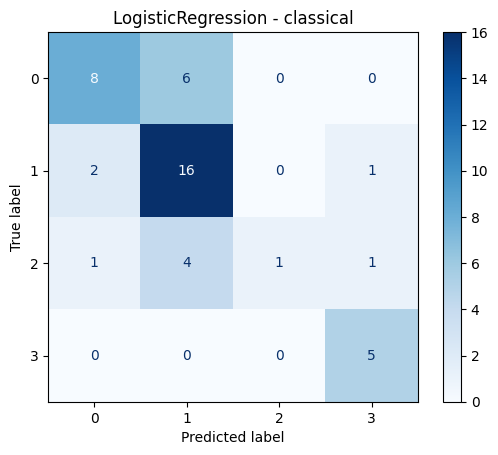


----------------------------------------------------------------------
🤖 MODEL → KNeighborsClassifier
----------------------------------------------------------------------
✅ Best Params: {'weights': 'distance', 'n_neighbors': 5, 'metric': 'manhattan'}
✅ CV Score   : 0.5555

📊 Train Accuracy : 1.0000
📊 Test Accuracy  : 0.6889

📈 Train F1 : 1.0000
📈 Test F1  : 0.6639

📉 Train Loss : 0.0000
📉 Test Loss  : 3.8133

📌 Kappa Score : 0.5202

⚠️ Overfitting Gap : 0.3111
❌ Severe Overfitting - Consider rejecting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.77      0.71      0.74        14
           1       0.65      0.89      0.76        19
           2       0.33      0.14      0.20         7
           3       1.00      0.60      0.75         5

    accuracy                           0.69        45
   macro avg       0.69      0.59      0.61        45
weighted avg       0.68      0.69      0.66        45



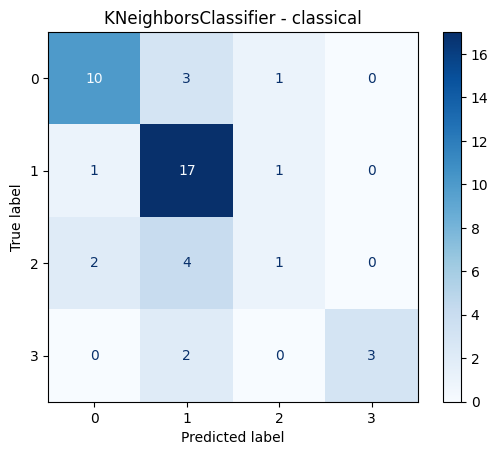


----------------------------------------------------------------------
🤖 MODEL → DecisionTreeClassifier
----------------------------------------------------------------------
✅ Best Params: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 7, 'criterion': 'entropy'}
✅ CV Score   : 0.5477

📊 Train Accuracy : 0.8295
📊 Test Accuracy  : 0.5556

📈 Train F1 : 0.8240
📈 Test F1  : 0.5457

📉 Train Loss : 0.3583
📉 Test Loss  : 11.4852

📌 Kappa Score : 0.3338

⚠️ Overfitting Gap : 0.2740
❌ Severe Overfitting - Consider rejecting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.62      0.57      0.59        14
           1       0.57      0.68      0.62        19
           2       0.20      0.14      0.17         7
           3       0.75      0.60      0.67         5

    accuracy                           0.56        45
   macro avg       0.53      0.50      0.51        45
weighted avg       0.54      0.56      0.55        45



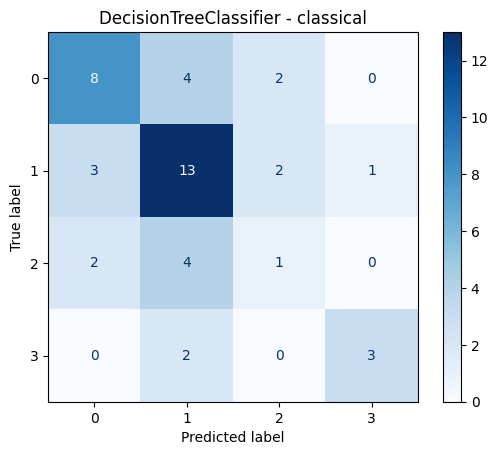


----------------------------------------------------------------------
🤖 MODEL → RandomForestClassifier
----------------------------------------------------------------------
✅ Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None, 'bootstrap': True}
✅ CV Score   : 0.6077

📊 Train Accuracy : 0.7784
📊 Test Accuracy  : 0.6444

📈 Train F1 : 0.7653
📈 Test F1  : 0.6119

📉 Train Loss : 0.5642
📉 Test Loss  : 0.9675

📌 Kappa Score : 0.4500

⚠️ Overfitting Gap : 0.1340
⚠️ Moderate Overfitting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.78      0.50      0.61        14
           1       0.59      0.89      0.71        19
           2       0.50      0.14      0.22         7
           3       0.80      0.80      0.80         5

    accuracy                           0.64        45
   macro avg       0.67      0.58      0.58        45
weighted avg  

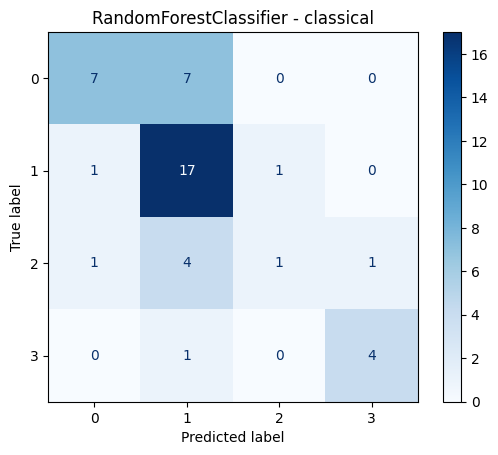


----------------------------------------------------------------------
🤖 MODEL → AdaBoostClassifier
----------------------------------------------------------------------
✅ Best Params: {'n_estimators': 200, 'learning_rate': 0.05}
✅ CV Score   : 0.5033

📊 Train Accuracy : 0.5682
📊 Test Accuracy  : 0.5333

📈 Train F1 : 0.5136
📈 Test F1  : 0.4931

📉 Train Loss : 1.3211
📉 Test Loss  : 1.3289

📌 Kappa Score : 0.2900

⚠️ Overfitting Gap : 0.0348
✅ Good Generalization

📋 Classification Report

              precision    recall  f1-score   support

           0       0.48      0.71      0.57        14
           1       0.50      0.53      0.51        19
           2       0.00      0.00      0.00         7
           3       1.00      0.80      0.89         5

    accuracy                           0.53        45
   macro avg       0.49      0.51      0.49        45
weighted avg       0.47      0.53      0.49        45



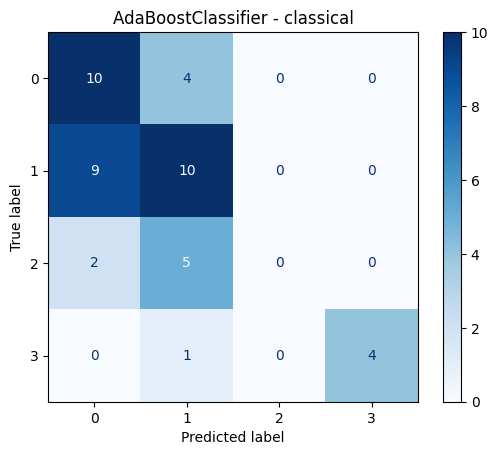


----------------------------------------------------------------------
🤖 MODEL → XGBClassifier
----------------------------------------------------------------------
✅ Best Params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.7}
✅ CV Score   : 0.5743

📊 Train Accuracy : 0.8011
📊 Test Accuracy  : 0.6667

📈 Train F1 : 0.7894
📈 Test F1  : 0.6583

📉 Train Loss : 0.5485
📉 Test Loss  : 0.9663

📌 Kappa Score : 0.4948

⚠️ Overfitting Gap : 0.1345
⚠️ Moderate Overfitting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.70      0.50      0.58        14
           1       0.62      0.84      0.71        19
           2       0.60      0.43      0.50         7
           3       1.00      0.80      0.89         5

    accuracy                           0.67        45
   macro avg       0.73      0.64      0.67        45
weighted avg       0.68  

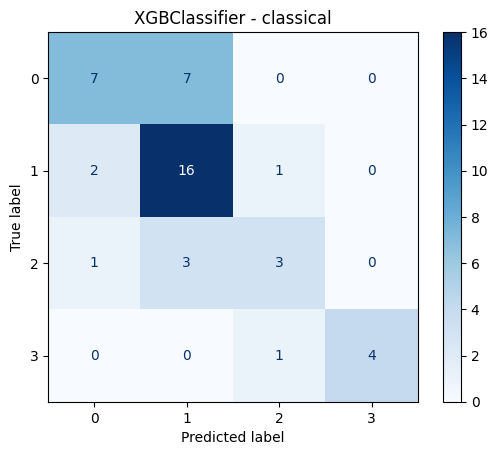


🧪 EVALUATION → CLASSICAL
✅ Features after filtering: 8

✅ Train shape : (320, 8)
✅ Test shape  : (80, 8)

----------------------------------------------------------------------
🤖 MODEL → LogisticRegression
----------------------------------------------------------------------
✅ Best Params: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 2000, 'class_weight': None, 'C': np.float64(10.0)}
✅ CV Score   : 0.6129

📊 Train Accuracy : 0.6500
📊 Test Accuracy  : 0.5625

📈 Train F1 : 0.6412
📈 Test F1  : 0.5520

📉 Train Loss : 0.8417
📉 Test Loss  : 0.8503

📌 Kappa Score : 0.4167

⚠️ Overfitting Gap : 0.0875
⚠️ Moderate Overfitting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.68      0.75      0.71        20
           1       0.39      0.35      0.37        20
           2       0.33      0.30      0.32        20
           3       0.77      0.85      0.81        20

    accuracy                           0.56        80
   macro avg     

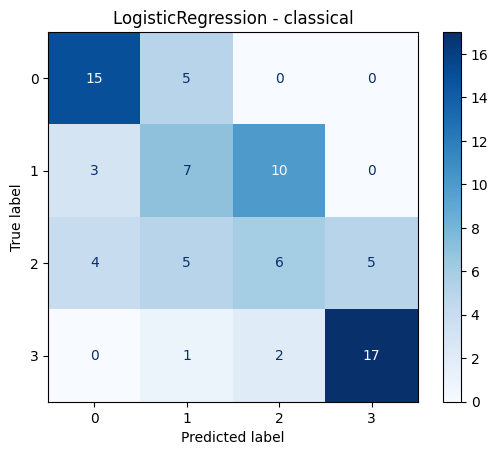


----------------------------------------------------------------------
🤖 MODEL → KNeighborsClassifier
----------------------------------------------------------------------
✅ Best Params: {'weights': 'distance', 'n_neighbors': 7, 'metric': 'manhattan'}
✅ CV Score   : 0.7373

📊 Train Accuracy : 1.0000
📊 Test Accuracy  : 0.7500

📈 Train F1 : 1.0000
📈 Test F1  : 0.7490

📉 Train Loss : 0.0000
📉 Test Loss  : 1.4805

📌 Kappa Score : 0.6667

⚠️ Overfitting Gap : 0.2500
❌ Severe Overfitting - Consider rejecting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.74      0.70      0.72        20
           1       0.61      0.70      0.65        20
           2       0.81      0.65      0.72        20
           3       0.86      0.95      0.90        20

    accuracy                           0.75        80
   macro avg       0.76      0.75      0.75        80
weighted avg       0.76      0.75      0.75        80



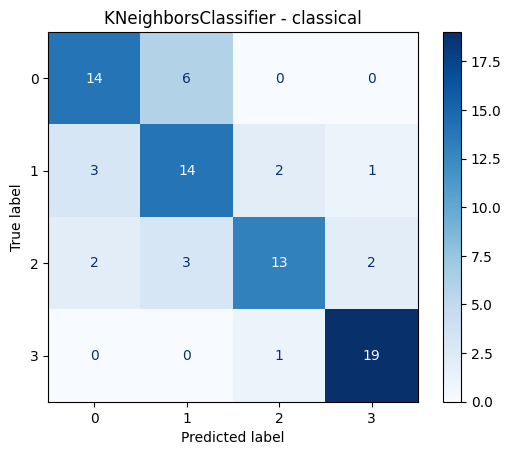


----------------------------------------------------------------------
🤖 MODEL → DecisionTreeClassifier
----------------------------------------------------------------------
✅ Best Params: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 7, 'criterion': 'gini'}
✅ CV Score   : 0.6351

📊 Train Accuracy : 0.8313
📊 Test Accuracy  : 0.6875

📈 Train F1 : 0.8317
📈 Test F1  : 0.6888

📉 Train Loss : 0.3640
📉 Test Loss  : 4.5096

📌 Kappa Score : 0.5833

⚠️ Overfitting Gap : 0.1438
⚠️ Moderate Overfitting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.68      0.75      0.71        20
           1       0.61      0.55      0.58        20
           2       0.61      0.70      0.65        20
           3       0.88      0.75      0.81        20

    accuracy                           0.69        80
   macro avg       0.70      0.69      0.69        80
weighted avg       0.70      0.69      0.69        80



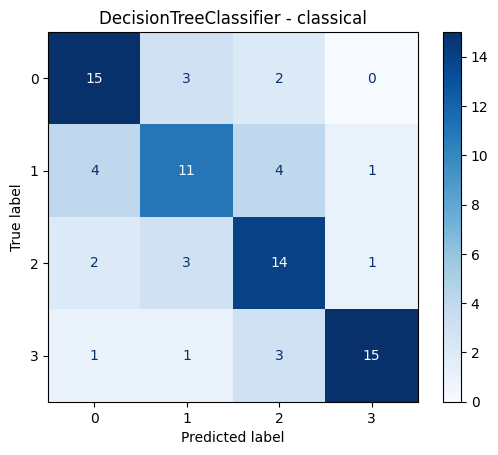


----------------------------------------------------------------------
🤖 MODEL → RandomForestClassifier
----------------------------------------------------------------------
✅ Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None, 'bootstrap': True}
✅ CV Score   : 0.7033

📊 Train Accuracy : 0.9031
📊 Test Accuracy  : 0.7125

📈 Train F1 : 0.9032
📈 Test F1  : 0.7148

📉 Train Loss : 0.4619
📉 Test Loss  : 0.7606

📌 Kappa Score : 0.6167

⚠️ Overfitting Gap : 0.1906
❌ Severe Overfitting - Consider rejecting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.72      0.65      0.68        20
           1       0.57      0.60      0.59        20
           2       0.64      0.70      0.67        20
           3       0.95      0.90      0.92        20

    accuracy                           0.71        80
   macro avg       0.72      0.71      0.71       

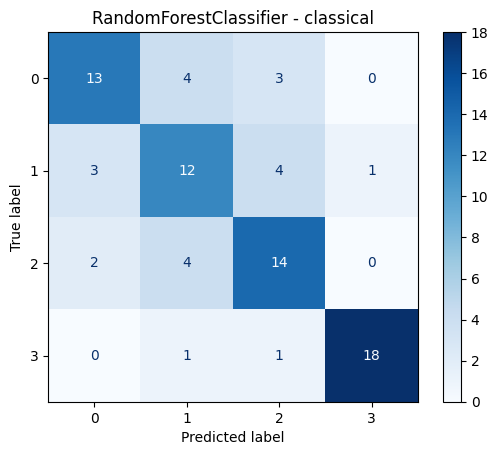


----------------------------------------------------------------------
🤖 MODEL → AdaBoostClassifier
----------------------------------------------------------------------
✅ Best Params: {'n_estimators': 200, 'learning_rate': 0.1}
✅ CV Score   : 0.5502

📊 Train Accuracy : 0.6438
📊 Test Accuracy  : 0.5625

📈 Train F1 : 0.6466
📈 Test F1  : 0.5647

📉 Train Loss : 1.3290
📉 Test Loss  : 1.3341

📌 Kappa Score : 0.4167

⚠️ Overfitting Gap : 0.0813
⚠️ Moderate Overfitting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.62      0.65      0.63        20
           1       0.37      0.35      0.36        20
           2       0.45      0.50      0.48        20
           3       0.83      0.75      0.79        20

    accuracy                           0.56        80
   macro avg       0.57      0.56      0.56        80
weighted avg       0.57      0.56      0.56        80



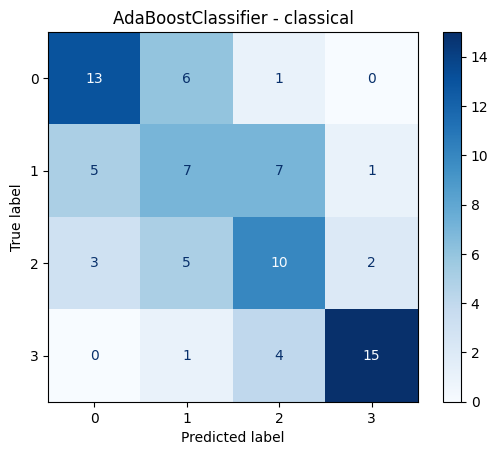


----------------------------------------------------------------------
🤖 MODEL → XGBClassifier
----------------------------------------------------------------------
✅ Best Params: {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}
✅ CV Score   : 0.6898

📊 Train Accuracy : 0.8625
📊 Test Accuracy  : 0.7375

📈 Train F1 : 0.8614
📈 Test F1  : 0.7405

📉 Train Loss : 0.5505
📉 Test Loss  : 0.7640

📌 Kappa Score : 0.6500

⚠️ Overfitting Gap : 0.1250
⚠️ Moderate Overfitting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.71      0.75      0.73        20
           1       0.60      0.60      0.60        20
           2       0.67      0.70      0.68        20
           3       1.00      0.90      0.95        20

    accuracy                           0.74        80
   macro avg       0.75      0.74      0.74        80
weighted avg       0.75  

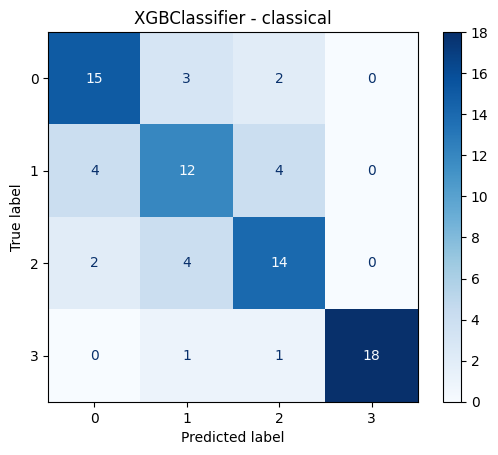


🧪 EVALUATION → TSFRESH
✅ Features after filtering: 42

✅ Train shape : (176, 42)
✅ Test shape  : (45, 42)

----------------------------------------------------------------------
🤖 MODEL → LogisticRegression
----------------------------------------------------------------------
✅ Best Params: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 2000, 'class_weight': None, 'C': np.float64(0.1668100537200059)}
✅ CV Score   : 0.6532

📊 Train Accuracy : 0.7216
📊 Test Accuracy  : 0.6222

📈 Train F1 : 0.7019
📈 Test F1  : 0.6187

📉 Train Loss : 0.7127
📉 Test Loss  : 0.9858

📌 Kappa Score : 0.4484

⚠️ Overfitting Gap : 0.0994
⚠️ Moderate Overfitting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.60      0.64      0.62        14
           1       0.68      0.68      0.68        19
           2       0.33      0.29      0.31         7
           3       0.80      0.80      0.80         5

    accuracy                           0.62        45
  

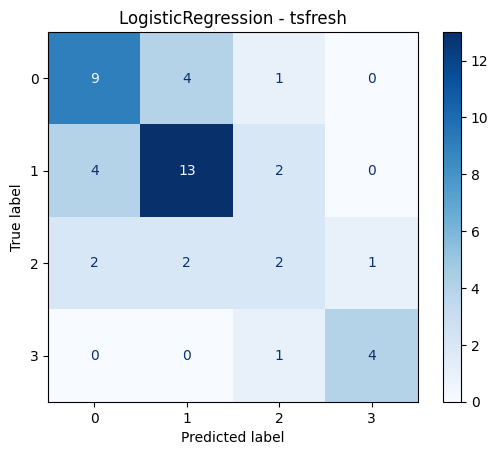


----------------------------------------------------------------------
🤖 MODEL → KNeighborsClassifier
----------------------------------------------------------------------
✅ Best Params: {'weights': 'distance', 'n_neighbors': 7, 'metric': 'euclidean'}
✅ CV Score   : 0.6946

📊 Train Accuracy : 1.0000
📊 Test Accuracy  : 0.6222

📈 Train F1 : 1.0000
📈 Test F1  : 0.6257

📉 Train Loss : 0.0000
📉 Test Loss  : 3.0332

📌 Kappa Score : 0.4578

⚠️ Overfitting Gap : 0.3778
❌ Severe Overfitting - Consider rejecting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.60      0.64      0.62        14
           1       0.71      0.63      0.67        19
           2       0.38      0.43      0.40         7
           3       0.80      0.80      0.80         5

    accuracy                           0.62        45
   macro avg       0.62      0.63      0.62        45
weighted avg       0.63      0.62      0.63        45



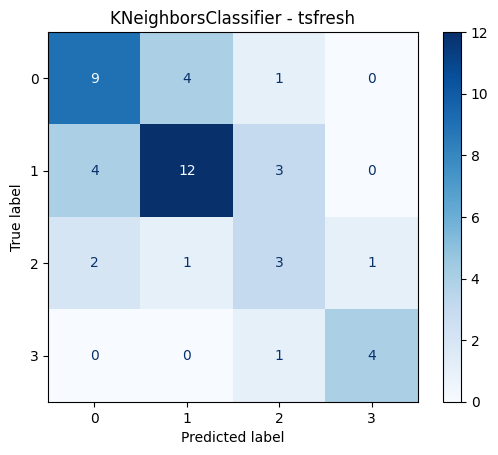


----------------------------------------------------------------------
🤖 MODEL → DecisionTreeClassifier
----------------------------------------------------------------------
✅ Best Params: {'min_samples_split': 5, 'min_samples_leaf': 5, 'max_depth': 3, 'criterion': 'entropy'}
✅ CV Score   : 0.6335

📊 Train Accuracy : 0.7500
📊 Test Accuracy  : 0.5778

📈 Train F1 : 0.7390
📈 Test F1  : 0.5737

📉 Train Loss : 0.6204
📉 Test Loss  : 4.0473

📌 Kappa Score : 0.3880

⚠️ Overfitting Gap : 0.1722
❌ Severe Overfitting - Consider rejecting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.59      0.71      0.65        14
           1       0.59      0.53      0.56        19
           2       0.50      0.43      0.46         7
           3       0.60      0.60      0.60         5

    accuracy                           0.58        45
   macro avg       0.57      0.57      0.57        45
weighted avg       0.58      0.58      0.57        45



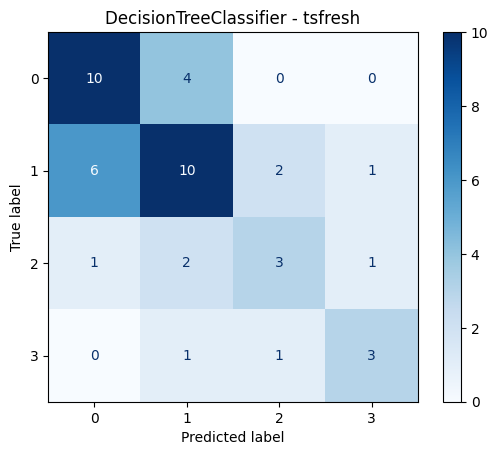


----------------------------------------------------------------------
🤖 MODEL → RandomForestClassifier
----------------------------------------------------------------------
✅ Best Params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 7, 'class_weight': None, 'bootstrap': True}
✅ CV Score   : 0.6587

📊 Train Accuracy : 0.8011
📊 Test Accuracy  : 0.6444

📈 Train F1 : 0.7847
📈 Test F1  : 0.6427

📉 Train Loss : 0.4976
📉 Test Loss  : 0.9019

📌 Kappa Score : 0.4809

⚠️ Overfitting Gap : 0.1567
❌ Severe Overfitting - Consider rejecting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.60      0.64      0.62        14
           1       0.68      0.68      0.68        19
           2       0.50      0.43      0.46         7
           3       0.80      0.80      0.80         5

    accuracy                           0.64        45
   macro avg       0.65      0.64      0.64       

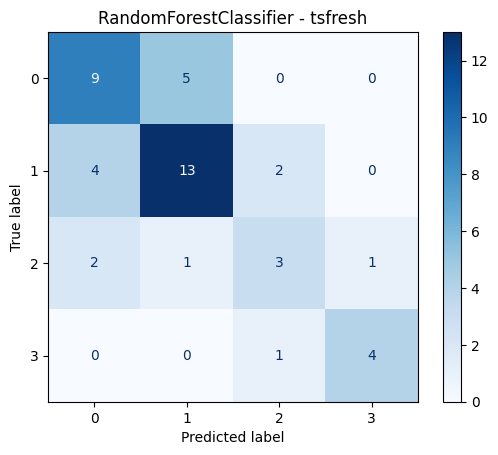


----------------------------------------------------------------------
🤖 MODEL → AdaBoostClassifier
----------------------------------------------------------------------
✅ Best Params: {'n_estimators': 200, 'learning_rate': 0.1}
✅ CV Score   : 0.6450

📊 Train Accuracy : 0.6989
📊 Test Accuracy  : 0.6000

📈 Train F1 : 0.6420
📈 Test F1  : 0.5493

📉 Train Loss : 1.3234
📉 Test Loss  : 1.3374

📌 Kappa Score : 0.3951

⚠️ Overfitting Gap : 0.0989
⚠️ Moderate Overfitting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.59      0.71      0.65        14
           1       0.59      0.68      0.63        19
           2       0.00      0.00      0.00         7
           3       0.67      0.80      0.73         5

    accuracy                           0.60        45
   macro avg       0.46      0.55      0.50        45
weighted avg       0.51      0.60      0.55        45



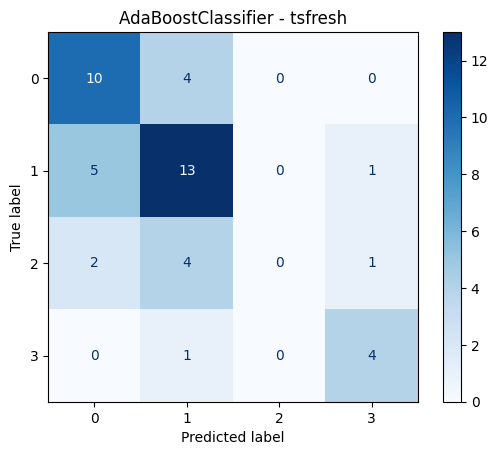


----------------------------------------------------------------------
🤖 MODEL → XGBClassifier
----------------------------------------------------------------------
✅ Best Params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.7}
✅ CV Score   : 0.6717

📊 Train Accuracy : 0.9261
📊 Test Accuracy  : 0.6222

📈 Train F1 : 0.9250
📈 Test F1  : 0.6199

📉 Train Loss : 0.3243
📉 Test Loss  : 0.9782

📌 Kappa Score : 0.4465

⚠️ Overfitting Gap : 0.3039
❌ Severe Overfitting - Consider rejecting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.57      0.57      0.57        14
           1       0.65      0.68      0.67        19
           2       0.50      0.43      0.46         7
           3       0.80      0.80      0.80         5

    accuracy                           0.62        45
   macro avg       0.63      0.62      0.62        45
weighte

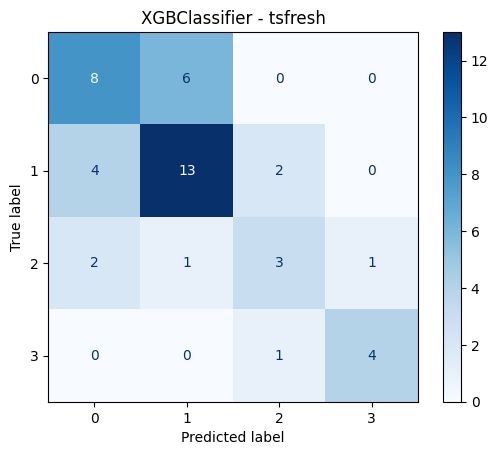


🧪 EVALUATION → TSFRESH
✅ Features after filtering: 50

✅ Train shape : (320, 50)
✅ Test shape  : (80, 50)

----------------------------------------------------------------------
🤖 MODEL → LogisticRegression
----------------------------------------------------------------------
✅ Best Params: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 2000, 'class_weight': None, 'C': np.float64(10.0)}
✅ CV Score   : 0.6889

📊 Train Accuracy : 0.6906
📊 Test Accuracy  : 0.8125

📈 Train F1 : 0.6916
📈 Test F1  : 0.8157

📉 Train Loss : 0.7141
📉 Test Loss  : 0.6183

📌 Kappa Score : 0.7500

⚠️ Overfitting Gap : -0.1219
⚠️ SUSPICIOUS: Test > Train - Check data split

📋 Classification Report

              precision    recall  f1-score   support

           0       0.94      0.75      0.83        20
           1       0.82      0.90      0.86        20
           2       0.65      0.85      0.74        20
           3       0.94      0.75      0.83        20

    accuracy                           0.81   

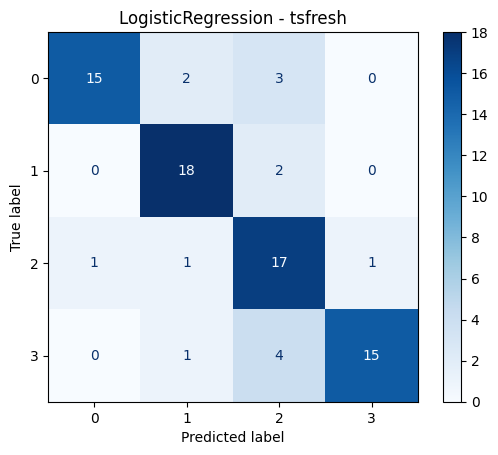


----------------------------------------------------------------------
🤖 MODEL → KNeighborsClassifier
----------------------------------------------------------------------
✅ Best Params: {'weights': 'uniform', 'n_neighbors': 3, 'metric': 'manhattan'}
✅ CV Score   : 0.8049

📊 Train Accuracy : 0.8750
📊 Test Accuracy  : 0.8250

📈 Train F1 : 0.8755
📈 Test F1  : 0.8262

📉 Train Loss : 0.2291
📉 Test Loss  : 3.7526

📌 Kappa Score : 0.7667

⚠️ Overfitting Gap : 0.0500
✅ Good Generalization

📋 Classification Report

              precision    recall  f1-score   support

           0       0.74      0.85      0.79        20
           1       0.79      0.75      0.77        20
           2       0.85      0.85      0.85        20
           3       0.94      0.85      0.89        20

    accuracy                           0.82        80
   macro avg       0.83      0.83      0.83        80
weighted avg       0.83      0.82      0.83        80



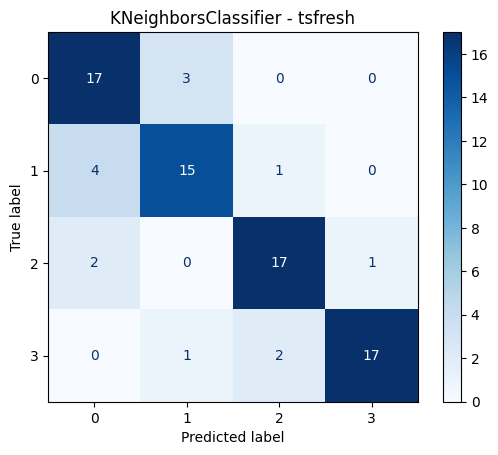


----------------------------------------------------------------------
🤖 MODEL → DecisionTreeClassifier
----------------------------------------------------------------------
✅ Best Params: {'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 7, 'criterion': 'gini'}
✅ CV Score   : 0.7663

📊 Train Accuracy : 0.8250
📊 Test Accuracy  : 0.8750

📈 Train F1 : 0.8256
📈 Test F1  : 0.8744

📉 Train Loss : 0.3671
📉 Test Loss  : 2.5359

📌 Kappa Score : 0.8333

⚠️ Overfitting Gap : -0.0500
⚠️ SUSPICIOUS: Test > Train - Check data split

📋 Classification Report

              precision    recall  f1-score   support

           0       0.89      0.85      0.87        20
           1       0.83      0.95      0.88        20
           2       0.89      0.80      0.84        20
           3       0.90      0.90      0.90        20

    accuracy                           0.88        80
   macro avg       0.88      0.87      0.87        80
weighted avg       0.88      0.88      0.87        80



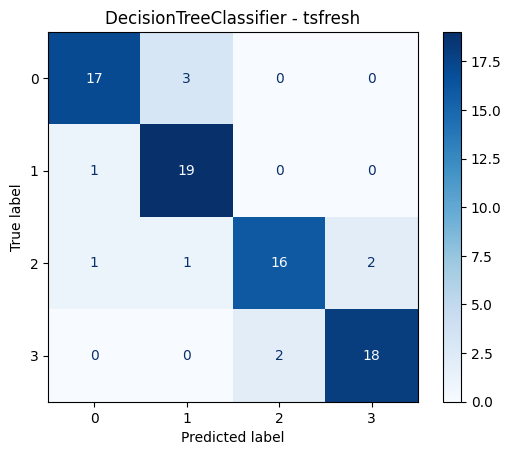


----------------------------------------------------------------------
🤖 MODEL → RandomForestClassifier
----------------------------------------------------------------------
✅ Best Params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': True}
✅ CV Score   : 0.7878

📊 Train Accuracy : 0.9187
📊 Test Accuracy  : 0.8500

📈 Train F1 : 0.9189
📈 Test F1  : 0.8509

📉 Train Loss : 0.2849
📉 Test Loss  : 0.4324

📌 Kappa Score : 0.8000

⚠️ Overfitting Gap : 0.0687
✅ Good Generalization

📋 Classification Report

              precision    recall  f1-score   support

           0       0.85      0.85      0.85        20
           1       0.76      0.80      0.78        20
           2       0.85      0.85      0.85        20
           3       0.95      0.90      0.92        20

    accuracy                           0.85        80
   macro avg       0.85      0.85      0.85        80
weighted 

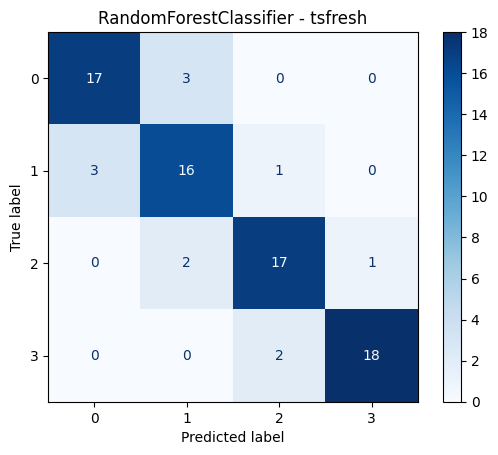


----------------------------------------------------------------------
🤖 MODEL → AdaBoostClassifier
----------------------------------------------------------------------
✅ Best Params: {'n_estimators': 200, 'learning_rate': 0.1}
✅ CV Score   : 0.7575

📊 Train Accuracy : 0.7688
📊 Test Accuracy  : 0.8750

📈 Train F1 : 0.7712
📈 Test F1  : 0.8768

📉 Train Loss : 1.3117
📉 Test Loss  : 1.3155

📌 Kappa Score : 0.8333

⚠️ Overfitting Gap : -0.1062
⚠️ SUSPICIOUS: Test > Train - Check data split

📋 Classification Report

              precision    recall  f1-score   support

           0       0.84      0.80      0.82        20
           1       0.76      0.95      0.84        20
           2       0.94      0.85      0.89        20
           3       1.00      0.90      0.95        20

    accuracy                           0.88        80
   macro avg       0.89      0.88      0.88        80
weighted avg       0.89      0.88      0.88        80



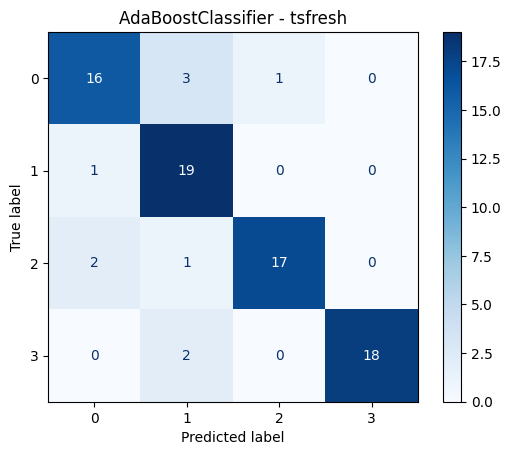


----------------------------------------------------------------------
🤖 MODEL → XGBClassifier
----------------------------------------------------------------------
✅ Best Params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.7}
✅ CV Score   : 0.7874

📊 Train Accuracy : 0.8812
📊 Test Accuracy  : 0.8625

📈 Train F1 : 0.8817
📈 Test F1  : 0.8631

📉 Train Loss : 0.3290
📉 Test Loss  : 0.4332

📌 Kappa Score : 0.8167

⚠️ Overfitting Gap : 0.0187
✅ Excellent Generalization

📋 Classification Report

              precision    recall  f1-score   support

           0       0.85      0.85      0.85        20
           1       0.78      0.90      0.84        20
           2       0.89      0.80      0.84        20
           3       0.95      0.90      0.92        20

    accuracy                           0.86        80
   macro avg       0.87      0.86      0.86        80
weighted avg       0.8

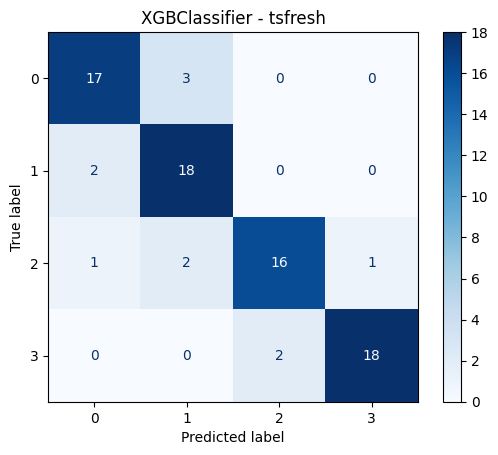


🧪 EVALUATION → FI_TSFRESH
✅ Features after filtering: 17

✅ Train shape : (176, 17)
✅ Test shape  : (45, 17)

----------------------------------------------------------------------
🤖 MODEL → LogisticRegression
----------------------------------------------------------------------
✅ Best Params: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 2000, 'class_weight': None, 'C': np.float64(1.2915496650148828)}
✅ CV Score   : 0.4020

📊 Train Accuracy : 0.4943
📊 Test Accuracy  : 0.4667

📈 Train F1 : 0.4474
📈 Test F1  : 0.4171

📉 Train Loss : 1.0831
📉 Test Loss  : 1.2217

📌 Kappa Score : 0.1523

⚠️ Overfitting Gap : 0.0277
✅ Excellent Generalization

📋 Classification Report

              precision    recall  f1-score   support

           0       0.39      0.50      0.44        14
           1       0.50      0.68      0.58        19
           2       0.00      0.00      0.00         7
           3       1.00      0.20      0.33         5

    accuracy                           0.47       

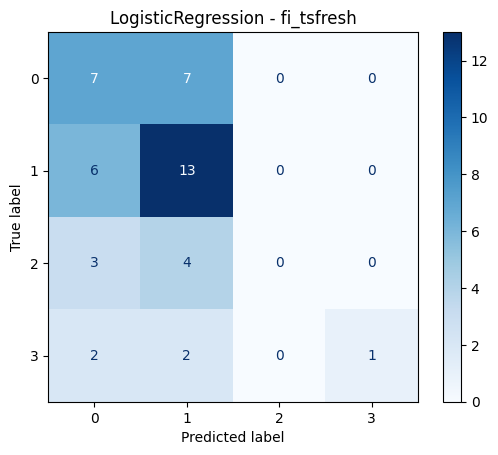


----------------------------------------------------------------------
🤖 MODEL → KNeighborsClassifier
----------------------------------------------------------------------
✅ Best Params: {'weights': 'uniform', 'n_neighbors': 11, 'metric': 'manhattan'}
✅ CV Score   : 0.3841

📊 Train Accuracy : 0.5114
📊 Test Accuracy  : 0.4444

📈 Train F1 : 0.4755
📈 Test F1  : 0.3995

📉 Train Loss : 1.0015
📉 Test Loss  : 2.6817

📌 Kappa Score : 0.1238

⚠️ Overfitting Gap : 0.0669
✅ Good Generalization

📋 Classification Report

              precision    recall  f1-score   support

           0       0.40      0.57      0.47        14
           1       0.46      0.58      0.51        19
           2       0.00      0.00      0.00         7
           3       1.00      0.20      0.33         5

    accuracy                           0.44        45
   macro avg       0.46      0.34      0.33        45
weighted avg       0.43      0.44      0.40        45



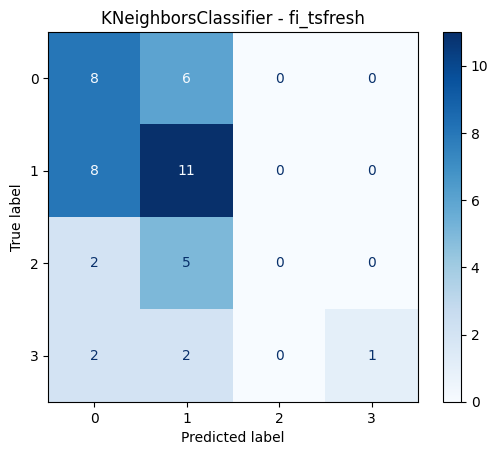


----------------------------------------------------------------------
🤖 MODEL → DecisionTreeClassifier
----------------------------------------------------------------------
✅ Best Params: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 7, 'criterion': 'entropy'}
✅ CV Score   : 0.3994

📊 Train Accuracy : 0.6761
📊 Test Accuracy  : 0.3333

📈 Train F1 : 0.6628
📈 Test F1  : 0.2894

📉 Train Loss : 0.6065
📉 Test Loss  : 10.2807

📌 Kappa Score : -0.0481

⚠️ Overfitting Gap : 0.3428
❌ Severe Overfitting - Consider rejecting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.25      0.29      0.27        14
           1       0.42      0.58      0.49        19
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00         5

    accuracy                           0.33        45
   macro avg       0.17      0.22      0.19        45
weighted avg       0.26      0.33      0.29        45



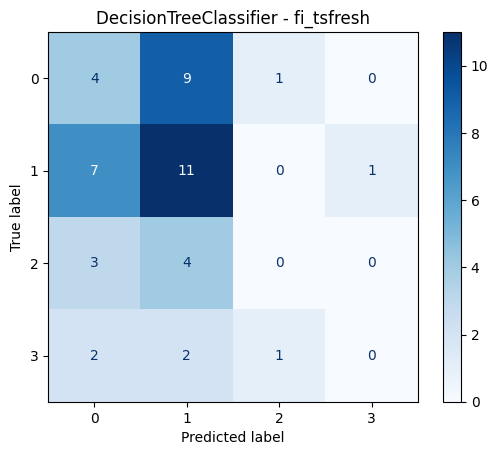


----------------------------------------------------------------------
🤖 MODEL → RandomForestClassifier
----------------------------------------------------------------------
✅ Best Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': True}
✅ CV Score   : 0.4149

📊 Train Accuracy : 0.7443
📊 Test Accuracy  : 0.4444

📈 Train F1 : 0.7424
📈 Test F1  : 0.4328

📉 Train Loss : 0.7649
📉 Test Loss  : 1.9472

📌 Kappa Score : 0.1999

⚠️ Overfitting Gap : 0.2999
❌ Severe Overfitting - Consider rejecting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.50      0.71      0.59        14
           1       0.50      0.37      0.42        19
           2       0.22      0.29      0.25         7
           3       0.50      0.20      0.29         5

    accuracy                           0.44        45
   macro avg       0.43      0.39      0.39 

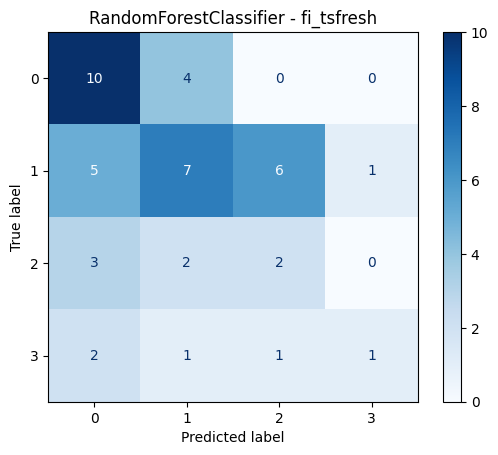


----------------------------------------------------------------------
🤖 MODEL → AdaBoostClassifier
----------------------------------------------------------------------
✅ Best Params: {'n_estimators': 200, 'learning_rate': 0.1}
✅ CV Score   : 0.2956

📊 Train Accuracy : 0.4602
📊 Test Accuracy  : 0.4444

📈 Train F1 : 0.3187
📈 Test F1  : 0.2917

📉 Train Loss : 1.3444
📉 Test Loss  : 1.3514

📌 Kappa Score : 0.0498

⚠️ Overfitting Gap : 0.0158
✅ Excellent Generalization

📋 Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.43      1.00      0.60        19
           2       0.00      0.00      0.00         7
           3       1.00      0.20      0.33         5

    accuracy                           0.44        45
   macro avg       0.36      0.30      0.23        45
weighted avg       0.29      0.44      0.29        45



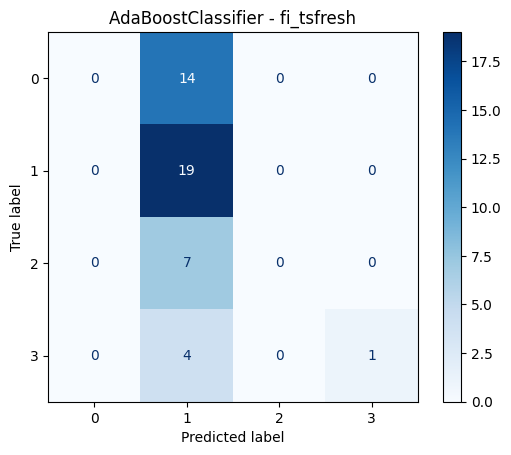


----------------------------------------------------------------------
🤖 MODEL → XGBClassifier
----------------------------------------------------------------------
✅ Best Params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.7}
✅ CV Score   : 0.3660

📊 Train Accuracy : 0.7273
📊 Test Accuracy  : 0.4444

📈 Train F1 : 0.7011
📈 Test F1  : 0.3887

📉 Train Loss : 0.7977
📉 Test Loss  : 1.1982

📌 Kappa Score : 0.0993

⚠️ Overfitting Gap : 0.2828
❌ Severe Overfitting - Consider rejecting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.38      0.36      0.37        14
           1       0.45      0.74      0.56        19
           2       0.00      0.00      0.00         7
           3       1.00      0.20      0.33         5

    accuracy                           0.44        45
   macro avg       0.46      0.32      0.32        45
weighte

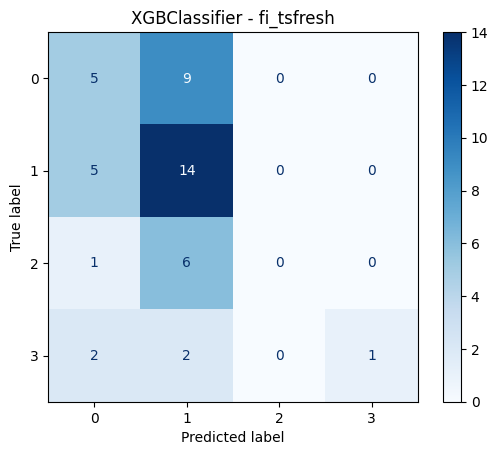


🧪 EVALUATION → FI_TSFRESH
✅ Features after filtering: 23

✅ Train shape : (320, 23)
✅ Test shape  : (80, 23)

----------------------------------------------------------------------
🤖 MODEL → LogisticRegression
----------------------------------------------------------------------
✅ Best Params: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 2000, 'class_weight': None, 'C': np.float64(1.2915496650148828)}
✅ CV Score   : 0.4789

📊 Train Accuracy : 0.5344
📊 Test Accuracy  : 0.4875

📈 Train F1 : 0.5297
📈 Test F1  : 0.4718

📉 Train Loss : 1.0622
📉 Test Loss  : 1.1877

📌 Kappa Score : 0.3167

⚠️ Overfitting Gap : 0.0469
✅ Good Generalization

📋 Classification Report

              precision    recall  f1-score   support

           0       0.47      0.45      0.46        20
           1       0.29      0.20      0.24        20
           2       0.50      0.55      0.52        20
           3       0.60      0.75      0.67        20

    accuracy                           0.49        80
 

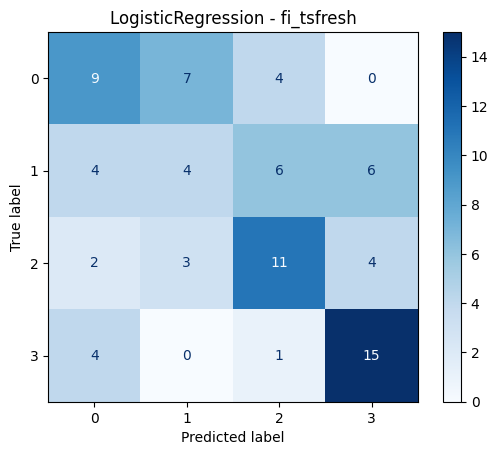


----------------------------------------------------------------------
🤖 MODEL → KNeighborsClassifier
----------------------------------------------------------------------
✅ Best Params: {'weights': 'distance', 'n_neighbors': 9, 'metric': 'manhattan'}
✅ CV Score   : 0.5931

📊 Train Accuracy : 1.0000
📊 Test Accuracy  : 0.6875

📈 Train F1 : 1.0000
📈 Test F1  : 0.6728

📉 Train Loss : 0.0000
📉 Test Loss  : 1.0336

📌 Kappa Score : 0.5833

⚠️ Overfitting Gap : 0.3125
❌ Severe Overfitting - Consider rejecting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.59      0.65      0.62        20
           1       0.54      0.35      0.42        20
           2       0.74      0.85      0.79        20
           3       0.82      0.90      0.86        20

    accuracy                           0.69        80
   macro avg       0.67      0.69      0.67        80
weighted avg       0.67      0.69      0.67        80



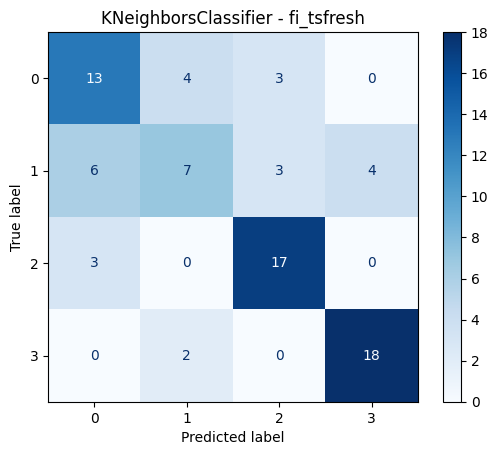


----------------------------------------------------------------------
🤖 MODEL → DecisionTreeClassifier
----------------------------------------------------------------------
✅ Best Params: {'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 10, 'criterion': 'gini'}
✅ CV Score   : 0.5238

📊 Train Accuracy : 0.7219
📊 Test Accuracy  : 0.5375

📈 Train F1 : 0.7234
📈 Test F1  : 0.5522

📉 Train Loss : 0.6124
📉 Test Loss  : 4.7603

📌 Kappa Score : 0.3833

⚠️ Overfitting Gap : 0.1844
❌ Severe Overfitting - Consider rejecting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.62      0.50      0.56        20
           1       0.31      0.45      0.37        20
           2       0.60      0.60      0.60        20
           3       0.80      0.60      0.69        20

    accuracy                           0.54        80
   macro avg       0.58      0.54      0.55        80
weighted avg       0.58      0.54      0.55        80



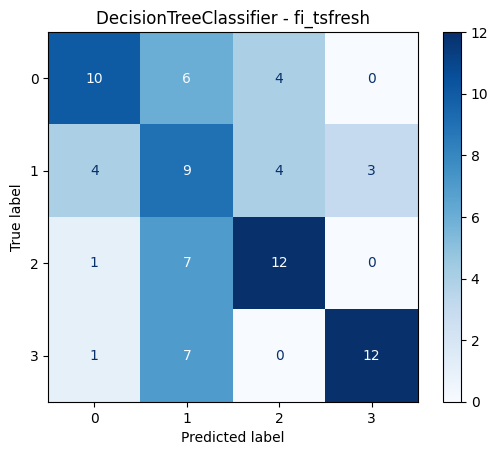


----------------------------------------------------------------------
🤖 MODEL → RandomForestClassifier
----------------------------------------------------------------------
✅ Best Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': True}
✅ CV Score   : 0.5545

📊 Train Accuracy : 0.8500
📊 Test Accuracy  : 0.6625

📈 Train F1 : 0.8490
📈 Test F1  : 0.6478

📉 Train Loss : 0.5757
📉 Test Loss  : 0.8708

📌 Kappa Score : 0.5500

⚠️ Overfitting Gap : 0.1875
❌ Severe Overfitting - Consider rejecting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.58      0.70      0.64        20
           1       0.54      0.35      0.42        20
           2       0.70      0.95      0.81        20
           3       0.81      0.65      0.72        20

    accuracy                           0.66        80
   macro avg       0.66      0.66      0.65 

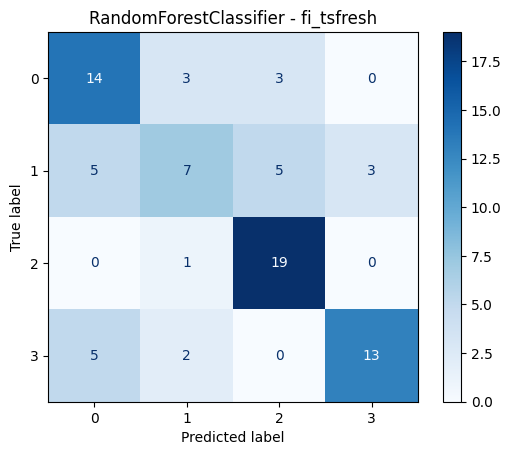


----------------------------------------------------------------------
🤖 MODEL → AdaBoostClassifier
----------------------------------------------------------------------
✅ Best Params: {'n_estimators': 200, 'learning_rate': 0.1}
✅ CV Score   : 0.4105

📊 Train Accuracy : 0.4688
📊 Test Accuracy  : 0.4375

📈 Train F1 : 0.4295
📈 Test F1  : 0.3892

📉 Train Loss : 1.3447
📉 Test Loss  : 1.3509

📌 Kappa Score : 0.2500

⚠️ Overfitting Gap : 0.0312
✅ Good Generalization

📋 Classification Report

              precision    recall  f1-score   support

           0       0.37      0.55      0.44        20
           1       0.00      0.00      0.00        20
           2       0.36      0.50      0.42        20
           3       0.70      0.70      0.70        20

    accuracy                           0.44        80
   macro avg       0.36      0.44      0.39        80
weighted avg       0.36      0.44      0.39        80



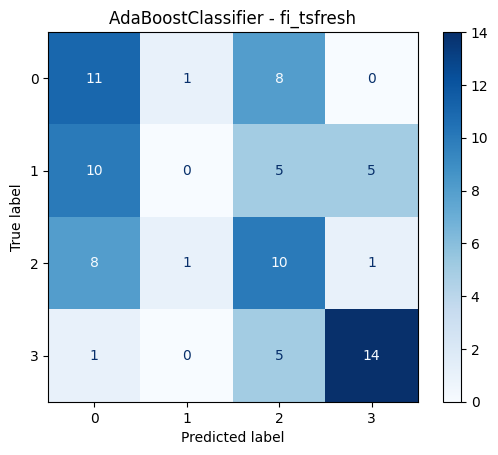


----------------------------------------------------------------------
🤖 MODEL → XGBClassifier
----------------------------------------------------------------------
✅ Best Params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.7}
✅ CV Score   : 0.5389

📊 Train Accuracy : 0.8406
📊 Test Accuracy  : 0.7125

📈 Train F1 : 0.8389
📈 Test F1  : 0.6984

📉 Train Loss : 0.5918
📉 Test Loss  : 0.8852

📌 Kappa Score : 0.6167

⚠️ Overfitting Gap : 0.1281
⚠️ Moderate Overfitting

📋 Classification Report

              precision    recall  f1-score   support

           0       0.71      0.75      0.73        20
           1       0.50      0.35      0.41        20
           2       0.72      0.90      0.80        20
           3       0.85      0.85      0.85        20

    accuracy                           0.71        80
   macro avg       0.70      0.71      0.70        80
weighted avg       0.70  

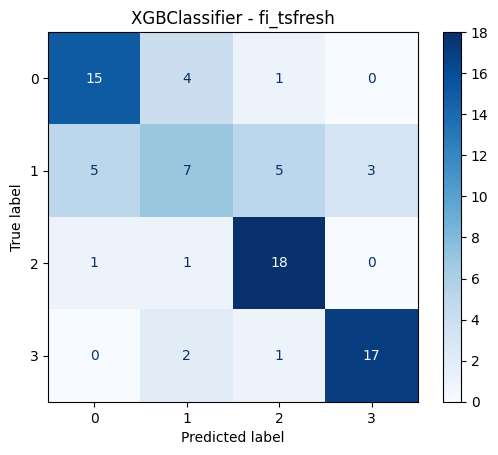


📊 TOP 10 MODELS (RANKED BY SCORE)
 Rank      Recommendation      Dataset Feature_Type                  Model Test_Accuracy Overfitting_Gap Test_F1 Final_Score
    1  ✅ Strong candidate fis_balanced      tsfresh          XGBClassifier        0.8625          0.0187  0.8631      0.7951
    2  ✅ Strong candidate fis_balanced      tsfresh RandomForestClassifier        0.8500          0.0687  0.8509      0.7109
    3  ✅ Strong candidate fis_balanced      tsfresh   KNeighborsClassifier        0.8250          0.0500  0.8262      0.7098
    4 ⚠️ High overfitting fis_balanced    classical          XGBClassifier        0.7375          0.1250  0.7405      0.5673
    5 ⚠️ High overfitting fis_balanced   fi_tsfresh          XGBClassifier        0.7125          0.1281  0.6984      0.5192
    6 ⚠️ High overfitting fis_balanced    classical DecisionTreeClassifier        0.6875          0.1438  0.6888      0.4962
    7            Consider          fis      tsfresh     LogisticRegression        0.6222  

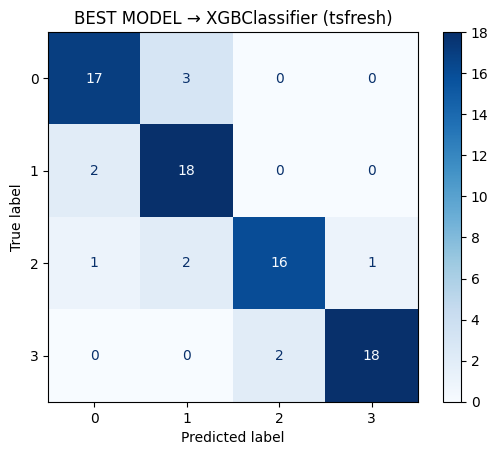


💾 Best model and scaler saved
💾 Results saved to ../result_files/final_results.csv

✅ PIPELINE FINISHED SUCCESSFULLY


In [ ]:
# =========================================================
# 🚀 IMPROVED PIPELINE
# REDUCED OVERFITTING + BETTER HYPERPARAMETER TUNING
# =========================================================

import sys
import os
import random
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
    cohen_kappa_score
)

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    learning_curve,
    cross_val_score,
    StratifiedKFold
)

warnings.filterwarnings("ignore")

# =========================================================
# PROJECT LIBRARIES
# =========================================================

sys.path.append(os.path.abspath(".."))

import lib.ml_models as m2t
import lib.extract_features as ef

from lib.data_augmentation import augment_dataset

# =========================================================
# RANDOM SEED
# =========================================================

np.random.seed(42)
random.seed(42)

# =========================================================
# DATASET
# =========================================================

dataset_identifier = "fis"

# =========================================================
# EVALUATION FUNCTION
# =========================================================

def evaluate_test_accuracy(
    dataset_identifier,
    features_type,
    test_size=0.2
):

    print("\n" + "="*80)
    print(f"🧪 EVALUATION → {features_type.upper()}")
    print("="*80)

    # =====================================================
    # LOAD LABELS
    # =====================================================

    diag_file = (
        f"../input_files/"
        f"{dataset_identifier}_diagnostic.csv"
    )

    y_diagnostic = pd.read_csv(
        diag_file,
        dtype={
            'UPDRS': int,
            'ID': str
        }
    )

    y_diagnostic = (
        y_diagnostic
        .sort_values(by=['ID'])
        .drop_duplicates()
        .reset_index(drop=True)
    )

    # =====================================================
    # LOAD FEATURES
    # =====================================================

    features_file = (
        f"../output_files/"
        f"{dataset_identifier}_{features_type}_features.csv"
    )

    features = pd.read_csv(features_file)

    if 'Unnamed: 0' in features.columns:
        features = features.rename(
            columns={"Unnamed: 0": "ID"}
        )

    # =====================================================
    # ALIGN IDS
    # =====================================================

    common_ids = np.intersect1d(
        features['ID'].values,
        y_diagnostic['ID'].values
    )

    features = features[
        features['ID'].isin(common_ids)
    ]

    y_diagnostic = y_diagnostic[
        y_diagnostic['ID'].isin(common_ids)
    ]

    # =====================================================
    # X / y
    # =====================================================

    X = features.drop(columns=['ID'])

    X = (
        X
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    y = (
        y_diagnostic
        .set_index('ID')
        .loc[features.set_index('ID').index]['UPDRS']
        .values
    )

    # =====================================================
    # REMOVE LOW VARIANCE FEATURES
    # =====================================================

    from sklearn.feature_selection import VarianceThreshold

    selector = VarianceThreshold(threshold=0.01)

    X = selector.fit_transform(X)

    print(f"✅ Features after filtering: {X.shape[1]}")

    # =====================================================
    # SPLIT
    # =====================================================

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=42
    )

    # =====================================================
    # SCALING
    # =====================================================

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    print(f"\n✅ Train shape : {X_train.shape}")
    print(f"✅ Test shape  : {X_test.shape}")

    # =====================================================
    # IMPROVED PARAMETER GRIDS
    # =====================================================

    param_grids = {

        "LogisticRegression": {

            "C": np.logspace(-3, 1, 10),
            "penalty": ['l2'],
            "solver": ['lbfgs'],
            "max_iter": [2000],
            "class_weight": [None, 'balanced']

        },

        "KNeighborsClassifier": {

            "n_neighbors": [3, 5, 7, 9, 11],
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan"]

        },

        "DecisionTreeClassifier": {

            "max_depth": [3, 5, 7, 10],
            "min_samples_split": [5, 10, 20],
            "min_samples_leaf": [2, 5, 10],
            "criterion": ["gini", "entropy"]

        },

        "RandomForestClassifier": {

            "n_estimators": [100, 200, 300],

            # REDUCE OVERFITTING
            "max_depth": [3, 5, 7, 10],

            "min_samples_split": [5, 10, 20],

            "min_samples_leaf": [2, 4, 8],

            "max_features": ["sqrt", "log2"],

            "bootstrap": [True],

            "class_weight": [None, "balanced"]

        },

        "AdaBoostClassifier": {

            "n_estimators": [50, 100, 200],
            "learning_rate": [0.001, 0.01, 0.05, 0.1]

        },

        "XGBClassifier": {

            "n_estimators": [50, 100, 200],

            # SMALLER TREES
            "max_depth": [2, 3, 4],

            # STRONGER REGULARIZATION
            "learning_rate": [0.005, 0.01, 0.05],

            "subsample": [0.7, 0.8],

            "colsample_bytree": [0.7, 0.8],

            "gamma": [0, 1, 5],

            "reg_alpha": [0, 0.1, 1],

            "reg_lambda": [1, 2, 5]

        }

    }

    # =====================================================
    # RESULTS
    # =====================================================

    results = []

    # =====================================================
    # MODELS LOOP
    # =====================================================

    for model_name, model_class in m2t.models.items():

        print("\n" + "-"*70)
        print(f"🤖 MODEL → {model_name}")
        print("-"*70)

        if model_name not in param_grids:
            print("⚠️ No param grid defined")
            continue

        try:

            # =================================================
            # MODEL INITIALIZATION
            # =================================================

            if model_name == "XGBClassifier":

                model = model_class(
                    eval_metric='mlogloss',
                    random_state=42,
                    use_label_encoder=False
                )

            else:

                model = model_class()

            # =================================================
            # RANDOMIZED SEARCH
            # =================================================

            cv_strategy = StratifiedKFold(
                n_splits=5,
                shuffle=True,
                random_state=42
            )

            search = RandomizedSearchCV(

                estimator=model,

                param_distributions=param_grids[model_name],

                n_iter=20,

                scoring='f1_weighted',

                cv=cv_strategy,

                n_jobs=-1,

                verbose=0,

                random_state=42

            )

            search.fit(X_train, y_train)

            best_model = search.best_estimator_

            best_params = search.best_params_

            cv_score = search.best_score_

            print(f"✅ Best Params: {best_params}")
            print(f"✅ CV Score   : {cv_score:.4f}")

            # =================================================
            # PREDICTIONS
            # =================================================

            y_pred_train = best_model.predict(X_train)
            y_pred_test = best_model.predict(X_test)

            # =================================================
            # METRICS
            # =================================================

            train_acc = accuracy_score(
                y_train,
                y_pred_train
            )

            test_acc = accuracy_score(
                y_test,
                y_pred_test
            )

            train_f1 = f1_score(
                y_train,
                y_pred_train,
                average='weighted'
            )

            test_f1 = f1_score(
                y_test,
                y_pred_test,
                average='weighted'
            )

            kappa = cohen_kappa_score(
                y_test,
                y_pred_test
            )

            overfitting_gap = train_acc - test_acc

            # =================================================
            # LOSS
            # =================================================

            if hasattr(best_model, "predict_proba"):

                y_prob_train = best_model.predict_proba(X_train)
                y_prob_test = best_model.predict_proba(X_test)

                train_loss = log_loss(y_train, y_prob_train)
                test_loss = log_loss(y_test, y_prob_test)

            else:

                train_loss = np.nan
                test_loss = np.nan

            # =================================================
            # PRINT
            # =================================================

            print(f"\n📊 Train Accuracy : {train_acc:.4f}")
            print(f"📊 Test Accuracy  : {test_acc:.4f}")

            print(f"\n📈 Train F1 : {train_f1:.4f}")
            print(f"📈 Test F1  : {test_f1:.4f}")

            print(f"\n📉 Train Loss : {train_loss:.4f}")
            print(f"📉 Test Loss  : {test_loss:.4f}")

            print(f"\n📌 Kappa Score : {kappa:.4f}")

            print(f"\n⚠️ Overfitting Gap : {overfitting_gap:.4f}")

            # =================================================
            # OVERFITTING STATUS
            # =================================================

            if overfitting_gap < 0.03 and overfitting_gap >= 0:
                print("✅ Excellent Generalization")
            elif 0.03 <= overfitting_gap < 0.08:
                print("✅ Good Generalization")
            elif 0.08 <= overfitting_gap < 0.15:
                print("⚠️ Moderate Overfitting")
            elif overfitting_gap >= 0.15:
                print("❌ Severe Overfitting - Consider rejecting")
            elif overfitting_gap < 0:
                print("⚠️ SUSPICIOUS: Test > Train - Check data split")

            # =================================================
            # CLASSIFICATION REPORT
            # =================================================

            print("\n📋 Classification Report\n")

            print(
                classification_report(
                    y_test,
                    y_pred_test,
                    zero_division=0
                )
            )

            # =================================================
            # CONFUSION MATRIX
            # =================================================

            cm = confusion_matrix(
                y_test,
                y_pred_test
            )

            disp = ConfusionMatrixDisplay(cm)

            disp.plot(cmap='Blues')

            plt.title(
                f"{model_name} - {features_type}"
            )

            plt.show()

            # =================================================
            # SAVE RESULTS
            # =================================================

            results.append({

                "Dataset": dataset_identifier,

                "Feature_Type": features_type,

                "Model": model_name,

                "Train_Accuracy": train_acc,
                "Test_Accuracy": test_acc,

                "CV_Score": cv_score,

                "Train_F1": train_f1,
                "Test_F1": test_f1,

                "Train_Loss": train_loss,
                "Test_Loss": test_loss,

                "Kappa": kappa,

                "Overfitting_Gap": overfitting_gap,

                "Best_Model": best_model,

                "Scaler": scaler,

                "Best_Params": str(best_params),

                "y_test": y_test,
                "y_pred": y_pred_test,

                "X_train": X_train,
                "y_train": y_train

            })

        except Exception as e:

            print(f"❌ ERROR with {model_name}: {e}")

            continue

    return results

# =========================================================
# ✅ CORRECTED SMART MODEL SELECTION
# =========================================================

def select_best_model(results_df):
    """
    Select best model using proper criteria:
    1. Prioritize test accuracy (real performance)
    2. Penalize overfitting (train > test)
    3. REJECT suspicious models (test > train by >3%)
    4. Consider CV score consistency
    """
    
    df = results_df.copy()
    
    if len(df) == 0:
        return df
    
    # =====================================================
    # STEP 1: REJECT UNACCEPTABLE MODELS
    # =====================================================
    
    # Reject severe overfitting (>15%)
    df = df[df['Overfitting_Gap'] <= 0.15]
    
    # REJECT suspicious models (test > train by more than 3%)
    # These indicate data leakage or test set issues
    df = df[df['Overfitting_Gap'] >= -0.03]
    
    if len(df) == 0:
        print("\n⚠️ All models rejected! Loosening criteria...")
        df = results_df.copy()
        df = df[df['Overfitting_Gap'] <= 0.20]
        df = df[df['Overfitting_Gap'] >= -0.05]
    
    # =====================================================
    # STEP 2: COMPUTE ROBUST SCORE
    # =====================================================
    
    def compute_model_score(row):
        """
        Score based on:
        - Test accuracy (primary, 50%)
        - Test F1 (25%)
        - CV score consistency (15%)
        - Negative overfitting penalty (10%)
        """
        
        test_acc = row['Test_Accuracy']
        test_f1 = row['Test_F1']
        cv_score = row['CV_Score']
        overfitting = row['Overfitting_Gap']
        
        # Base score
        score = (test_acc * 0.50) + (test_f1 * 0.25) + (cv_score * 0.15)
        
        # Penalty for overfitting (train much higher than test)
        if overfitting > 0.05:
            # Progressive penalty
            penalty = min(overfitting * 0.8, 0.15)
            score = score - penalty
        
        # Small bonus for very good generalization (gap < 2%)
        if 0 <= overfitting < 0.02:
            score = score + 0.02
        
        # Bonus for high kappa (agreement beyond chance)
        if 'Kappa' in row and row['Kappa'] > 0.6:
            score = score + 0.01
        
        return score
    
    df['Final_Score'] = df.apply(compute_model_score, axis=1)
    
    # =====================================================
    # STEP 3: SORT BY SCORE
    # =====================================================
    
    df = df.sort_values(
        by=['Final_Score', 'Test_Accuracy', 'Test_F1'],
        ascending=[False, False, False]
    ).reset_index(drop=True)
    
    # =====================================================
    # STEP 4: ADD RANKING INFO
    # =====================================================
    
    df['Rank'] = range(1, len(df) + 1)
    df['Recommendation'] = 'Consider'
    
    # Mark top models
    df.loc[df['Rank'] == 1, 'Recommendation'] = '⭐ BEST MODEL'
    df.loc[df['Rank'] <= 3, 'Recommendation'] = '✅ Strong candidate'
    
    # Mark problematic models (still in list but with warning)
    df.loc[df['Overfitting_Gap'] > 0.10, 'Recommendation'] = '⚠️ High overfitting'
    df.loc[df['Test_Accuracy'] < 0.60, 'Recommendation'] = '❌ Low accuracy'
    
    return df

# =========================================================
# MAIN PIPELINE
# =========================================================

print("\n🎯 COMPLETE PIPELINE")
print("="*80)

# =========================================================
# AUGMENTATION
# =========================================================

print("\n🧬 STEP 1 → DATA AUGMENTATION")

augment_dataset(
    dataset_identifier,
    n_augmentations=5
)

# =========================================================
# FEATURE EXTRACTION
# =========================================================

print("\n🔥 STEP 2 → FEATURE EXTRACTION")

ef.extract_all_features(dataset_identifier)

ef.extract_all_features(
    f"{dataset_identifier}_balanced"
)

# =========================================================
# EVALUATION
# =========================================================

feature_types = [
    "classical",
    "tsfresh",
    "fi_tsfresh"
]

all_results = []

for ft in feature_types:

    results_orig = evaluate_test_accuracy(
        dataset_identifier,
        ft
    )

    all_results.extend(results_orig)

    results_aug = evaluate_test_accuracy(
        f"{dataset_identifier}_balanced",
        ft
    )

    all_results.extend(results_aug)

# =========================================================
# RESULTS DATAFRAME
# =========================================================

results_df = pd.DataFrame(all_results)

if len(results_df) == 0:
    print("\n❌ No results collected! Exiting.")
    sys.exit(1)

results_df = select_best_model(results_df)

# =========================================================
# DISPLAY TOP 10 MODELS
# =========================================================

print("\n" + "="*80)
print("📊 TOP 10 MODELS (RANKED BY SCORE)")
print("="*80)

top10_display = results_df.head(10)[
    ['Rank', 'Recommendation', 'Dataset', 'Feature_Type', 'Model', 
     'Test_Accuracy', 'Overfitting_Gap', 'Test_F1', 'Final_Score']
].copy()

top10_display['Test_Accuracy'] = top10_display['Test_Accuracy'].map(lambda x: f"{x:.4f}")
top10_display['Overfitting_Gap'] = top10_display['Overfitting_Gap'].map(lambda x: f"{x:.4f}")
top10_display['Test_F1'] = top10_display['Test_F1'].map(lambda x: f"{x:.4f}")
top10_display['Final_Score'] = top10_display['Final_Score'].map(lambda x: f"{x:.4f}")

print(top10_display.to_string(index=False))

# =========================================================
# BEST MODEL
# =========================================================

best = results_df.iloc[0]

print("\n" + "🏆"*25)
print("🏆 BEST FINAL MODEL")
print("🏆"*25)

print(f"\n✅ Dataset      : {best['Dataset']}")
print(f"✅ Feature Type : {best['Feature_Type']}")
print(f"✅ Model        : {best['Model']}")
print(f"✅ Rank         : {best['Rank']}/{len(results_df)}")

print(f"\n📊 Train Accuracy : {best['Train_Accuracy']:.4f}")
print(f"📊 Test Accuracy  : {best['Test_Accuracy']:.4f}")
print(f"📊 CV Score       : {best['CV_Score']:.4f}")

print(f"\n📈 Train F1 : {best['Train_F1']:.4f}")
print(f"📈 Test F1  : {best['Test_F1']:.4f}")

print(f"\n📌 Kappa : {best['Kappa']:.4f}")

print(f"\n⚠️ Overfitting Gap : {best['Overfitting_Gap']:.4f}")

# Gap interpretation
gap = best['Overfitting_Gap']
if gap < 0:
    print("   ⚠️ WARNING: Test accuracy > Train accuracy")
    print("   → Possible data leakage or lucky test split")
elif gap < 0.03:
    print("   ✅ Excellent generalization")
elif gap < 0.08:
    print("   ✅ Good generalization")
elif gap < 0.12:
    print("   ⚠️ Acceptable overfitting")
else:
    print("   ❌ High overfitting - consider simpler model")

print(f"\n✅ Final Score : {best['Final_Score']:.4f}")

# =========================================================
# CROSS-VALIDATION VERIFICATION
# =========================================================

print("\n" + "="*80)
print("🔄 CROSS-VALIDATION VERIFICATION")
print("="*80)

best_model_obj = best['Best_Model']
X_train_cv = best['X_train']
y_train_cv = best['y_train']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    best_model_obj, 
    X_train_cv, 
    y_train_cv, 
    cv=cv, 
    scoring='accuracy'
)

print(f"\n📊 5-Fold CV scores: {cv_scores}")
print(f"📊 Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"📊 Reported test accuracy: {best['Test_Accuracy']:.4f}")

if abs(cv_scores.mean() - best['Test_Accuracy']) > 0.05:
    print("\n⚠️ WARNING: Large difference between CV and test accuracy!")
    print("   The test split may not be representative.")
    print(f"   Consider reporting CV mean: {cv_scores.mean():.4f}")

# =========================================================
# FINAL REPORT
# =========================================================

print("\n📋 FINAL CLASSIFICATION REPORT\n")

print(
    classification_report(
        best['y_test'],
        best['y_pred'],
        zero_division=0
    )
)

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    best['y_test'],
    best['y_pred']
)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap='Blues')

plt.title(
    f"BEST MODEL → "
    f"{best['Model']} "
    f"({best['Feature_Type']})"
)

plt.show()

# =========================================================
# SAVE
# =========================================================

import joblib

joblib.dump(
    best['Best_Model'],
    "../result_files/best_model.pkl"
)

joblib.dump(
    best['Scaler'],
    "../result_files/best_scaler.pkl"
)

print("\n💾 Best model and scaler saved")

# =========================================================
# SAVE RESULTS CSV
# =========================================================

exclude_cols = [
    'Best_Model',
    'Scaler',
    'X_train',
    'y_train',
    'y_test',
    'y_pred'
]

save_df = results_df.drop(
    columns=[c for c in exclude_cols if c in save_df.columns]
)

save_df.to_csv(
    "../result_files/final_results.csv",
    index=False
)

print("💾 Results saved to ../result_files/final_results.csv")

print("\n✅ PIPELINE FINISHED SUCCESSFULLY")

#Test


📂 CHARGEMENT DES DONNÉES
✅ Séquences chargées : (400, 150, 5)
✅ Labels : (400,) | Classes : [0 1 2 3]
✅ Normalisation terminée
Train : (240, 150, 5) | Val : (80, 150, 5) | Test : (80, 150, 5)
Vérification pourcentages : Train 60.0%, Val 20.0%, Test 20.0%
✅ Données augmentées : (960, 150, 5)

🔍 HYPERPARAMETER TUNING (Grid Search sur validation)
📊 Nombre total de combinaisons : 128

--- Combinaison 1/20 ---
{'conv_filters_1': 16, 'conv_filters_2': 32, 'lstm_units': 64, 'dropout_rate': 0.5, 'l2_reg': 0.005, 'learning_rate': 0.0005, 'batch_size': 32}
   Train acc: 0.7229 | Val acc: 0.6250

--- Combinaison 2/20 ---
{'conv_filters_1': 32, 'conv_filters_2': 32, 'lstm_units': 128, 'dropout_rate': 0.5, 'l2_reg': 0.01, 'learning_rate': 0.0005, 'batch_size': 16}
   Train acc: 0.7875 | Val acc: 0.7625

--- Combinaison 3/20 ---
{'conv_filters_1': 32, 'conv_filters_2': 64, 'lstm_units': 64, 'dropout_rate': 0.4, 'l2_reg': 0.01, 'learning_rate': 0.0001, 'batch_size': 16}
   Train acc: 0.7031 | Val ac

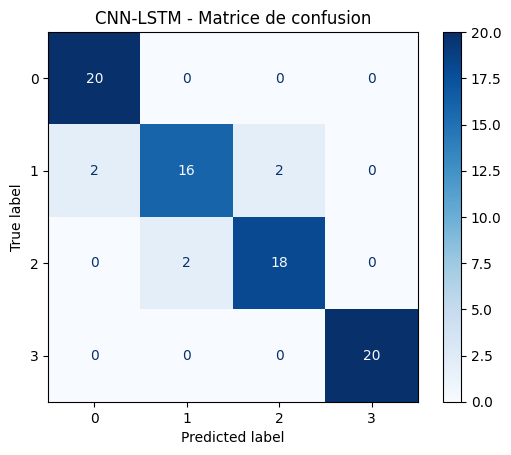

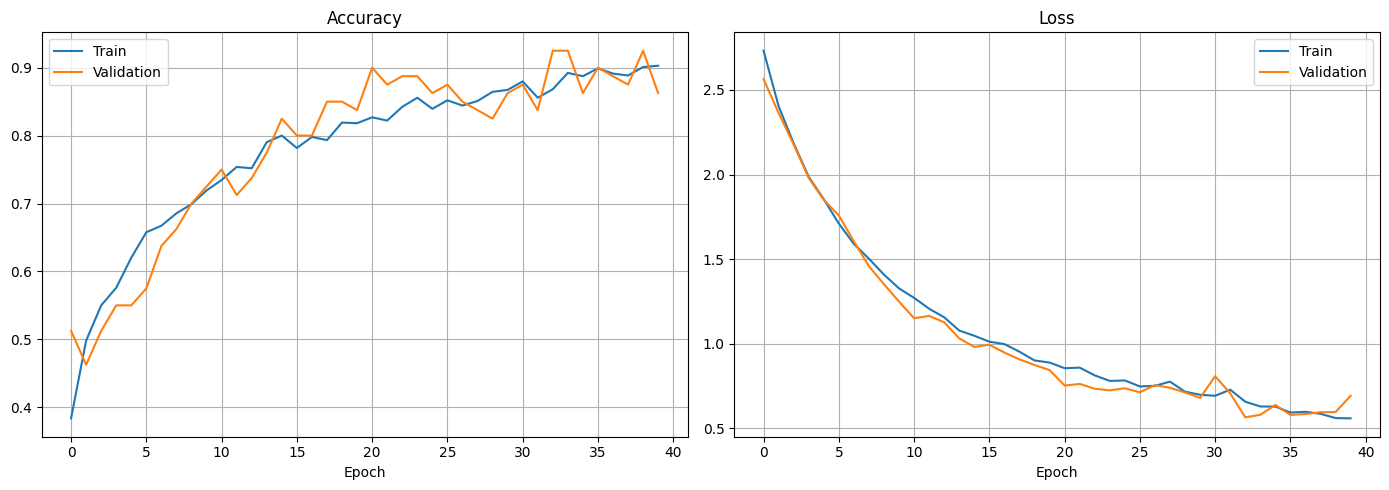


✅ Modèle et scaler sauvegardés dans ../result_files/


In [ ]:
# =========================================================
# 🔥 CNN-LSTM OPTIMISÉ POUR LA CLASSIFICATION UPDRS
# + Architecture réduite + Régularisation renforcée
# + Augmentation de données + Early stopping
# + SPLIT 80% TRAIN (incl. validation) / 20% TEST
# =========================================================

import os
import sys
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from itertools import product

# ---------------------------------------------------------
# 1. CONFIGURATION ET SEEDS
# ---------------------------------------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
tf.get_logger().setLevel('ERROR')

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 2. IMPORTS SPÉCIFIQUES
# ---------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, cohen_kappa_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, LSTM, Bidirectional,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.constraints import MaxNorm

from scipy.interpolate import interp1d

# ---------------------------------------------------------
# 3. CHARGEMENT DES DONNÉES
# ---------------------------------------------------------
print("\n" + "="*70)
print("📂 CHARGEMENT DES DONNÉES")
print("="*70)

dataset_identifier = "fis"
ts_file = f"../output_files/{dataset_identifier}_balanced_data_time_series.csv"
diag_file = f"../input_files/{dataset_identifier}_balanced_diagnostic.csv"

ts_data = pd.read_csv(ts_file)
labels = pd.read_csv(diag_file)

feature_cols = ['DISTANCE_ANG', 'SMOOTHED_AMPLITUDE', 'VELOCITY', 'ACCELERATION', 'FREQUENCY']
MAX_LEN = 150

X_seq = []
y_seq = []
video_ids = np.intersect1d(ts_data['ID'].unique(), labels['ID'].unique())

for vid in video_ids:
    seq = ts_data[ts_data['ID'] == vid][feature_cols].fillna(0).values
    if len(seq) > MAX_LEN:
        seq = seq[:MAX_LEN]
    else:
        pad = np.zeros((MAX_LEN - len(seq), len(feature_cols)))
        seq = np.vstack([seq, pad])
    X_seq.append(seq)
    label = labels[labels['ID'] == vid]['UPDRS'].iloc[0]
    y_seq.append(label)

X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq)

print(f"✅ Séquences chargées : {X_seq.shape}")
print(f"✅ Labels : {y_seq.shape} | Classes : {np.unique(y_seq)}")

# ---------------------------------------------------------
# 4. NORMALISATION
# ---------------------------------------------------------
scaler = StandardScaler()
X_flat = X_seq.reshape(-1, X_seq.shape[-1])
X_flat = scaler.fit_transform(X_flat)
X_seq = X_flat.reshape(X_seq.shape)
print("✅ Normalisation terminée")

# ---------------------------------------------------------
# 5. SPLIT 80% TRAIN (incl. validation) / 20% TEST
#    (Train+Val = 80% total, Test = 20% total)
#    Ensuite, de ces 80%, on prend 80% pour train et 20% pour val
#    → Train final = 64% total, Val = 16% total, Test = 20% total
# ---------------------------------------------------------
# D'abord séparer le test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, stratify=y_seq, random_state=SEED
)

# Puis diviser le reste (80%) en train (80% of 80% = 64% total) et val (20% of 80% = 16% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=SEED
)   # 0.25 x 0.8 = 0.2 de l'original, donc 0.2 -> val, 0.6 -> train ? 
    # Attention: 0.25 de 80% = 20% du total -> val = 20%? Non: on veut val = 16% total, donc test_size doit être 0.2 (20% de 80% = 16%).
    # Correction: Pour obtenir 16% val sur le total, il faut prendre test_size = 0.2 (car 0.2 * 0.8 = 0.16).
    # Mais train_test_split sur X_train_val (80% total) avec test_size=0.2 donnera 0.2*0.8=0.16 pour val et 0.8*0.8=0.64 pour train.
    # C'est exact. Donc test_size=0.2 est correct.
print(f"Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")
print(f"Vérification pourcentages : Train {len(X_train)/len(X_seq)*100:.1f}%, "
      f"Val {len(X_val)/len(X_seq)*100:.1f}%, Test {len(X_test)/len(X_seq)*100:.1f}%")

# ---------------------------------------------------------
# 6. AUGMENTATION DE DONNÉES (plus aggressive)
# ---------------------------------------------------------
def augment_sequence(seq, noise_std=0.03, time_warp_strength=0.07):
    noisy = seq + np.random.normal(0, noise_std, seq.shape)
    orig_len = seq.shape[0]
    new_len = int(orig_len * (1 + np.random.uniform(-time_warp_strength, time_warp_strength)))
    new_len = max(10, min(MAX_LEN, new_len))
    indices = np.linspace(0, orig_len-1, new_len)
    warped = np.zeros((new_len, seq.shape[1]))
    for f in range(seq.shape[1]):
        f_interp = interp1d(np.arange(orig_len), seq[:, f], kind='linear', fill_value="extrapolate")
        warped[:, f] = f_interp(indices)
    if new_len > MAX_LEN:
        warped = warped[:MAX_LEN]
    else:
        pad = np.zeros((MAX_LEN - new_len, seq.shape[1]))
        warped = np.vstack([warped, pad])
    return warped

X_train_aug = []
y_train_aug = []
for i in range(len(X_train)):
    X_train_aug.append(X_train[i])
    y_train_aug.append(y_train[i])
    for _ in range(3):   # 3 augmentations par échantillon
        X_train_aug.append(augment_sequence(X_train[i]))
        y_train_aug.append(y_train[i])
X_train_aug = np.array(X_train_aug)
y_train_aug = np.array(y_train_aug)
print(f"✅ Données augmentées : {X_train_aug.shape}")

# ---------------------------------------------------------
# 7. DÉFINITION D'UN MODÈLE PLUS PETIT ET PLUS RÉGULARISÉ
# ---------------------------------------------------------
input_shape = (X_train.shape[1], X_train.shape[2])
n_classes = len(np.unique(y_train))

def build_model(conv_filters_1=16, conv_filters_2=32, lstm_units=64,
                dropout_rate=0.5, l2_reg=0.01, learning_rate=0.0005):
    model = Sequential([
        Conv1D(filters=conv_filters_1, kernel_size=5, activation='relu',
               padding='same', kernel_regularizer=l2(l2_reg),
               kernel_constraint=MaxNorm(2), input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(dropout_rate),

        Conv1D(filters=conv_filters_2, kernel_size=3, activation='relu',
               padding='same', kernel_regularizer=l2(l2_reg),
               kernel_constraint=MaxNorm(2)),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(dropout_rate),

        Bidirectional(LSTM(units=lstm_units, return_sequences=False,
                           kernel_regularizer=l2(l2_reg))),
        Dropout(dropout_rate),

        Dense(units=32, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dropout(dropout_rate),
        Dense(units=n_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# ---------------------------------------------------------
# 8. HYPERPARAMETER TUNING (grille adaptée)
# ---------------------------------------------------------
print("\n" + "="*70)
print("🔍 HYPERPARAMETER TUNING (Grid Search sur validation)")
print("="*70)

param_grid = {
    'conv_filters_1': [16, 32],
    'conv_filters_2': [32, 64],
    'lstm_units': [64, 128],
    'dropout_rate': [0.4, 0.5],
    'l2_reg': [0.005, 0.01],
    'learning_rate': [0.0005, 0.0001],
    'batch_size': [16, 32]
}

keys = list(param_grid.keys())
values = list(param_grid.values())
combinations = [dict(zip(keys, v)) for v in product(*values)]
print(f"📊 Nombre total de combinaisons : {len(combinations)}")

best_val_acc = 0.0
best_params = None
tuning_log = []
max_combos = 20
random.shuffle(combinations)
combinations_to_test = combinations[:max_combos]

for idx, params in enumerate(combinations_to_test):
    print(f"\n--- Combinaison {idx+1}/{max_combos} ---")
    print(params)

    model = build_model(
        conv_filters_1=params['conv_filters_1'],
        conv_filters_2=params['conv_filters_2'],
        lstm_units=params['lstm_units'],
        dropout_rate=params['dropout_rate'],
        l2_reg=params['l2_reg'],
        learning_rate=params['learning_rate']
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)
    ]

    history = model.fit(
        X_train_aug, y_train_aug,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=params['batch_size'],
        callbacks=callbacks,
        verbose=0
    )

    val_acc = max(history.history['val_accuracy'])
    train_acc = max(history.history['accuracy'])
    print(f"   Train acc: {train_acc:.4f} | Val acc: {val_acc:.4f}")

    tuning_log.append({'params': params, 'val_acc': val_acc, 'train_acc': train_acc})

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = params

print("\n" + "="*70)
print("🏆 MEILLEURS HYPERPARAMÈTRES")
print("="*70)
for k, v in best_params.items():
    print(f"{k}: {v}")
print(f"Validation accuracy : {best_val_acc:.4f}")

# ---------------------------------------------------------
# 9. ENTRAÎNEMENT FINAL 
# ---------------------------------------------------------
print("\n" + "="*70)
print("🚀 ENTRAÎNEMENT FINAL")
print("="*70)

X_final_train = np.concatenate([X_train_aug, X_val], axis=0)
y_final_train = np.concatenate([y_train_aug, y_val], axis=0)

final_model = build_model(
    conv_filters_1=best_params['conv_filters_1'],
    conv_filters_2=best_params['conv_filters_2'],
    lstm_units=best_params['lstm_units'],
    dropout_rate=best_params['dropout_rate'],
    l2_reg=best_params['l2_reg'],
    learning_rate=best_params['learning_rate']
)

callbacks_final = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint("../result_files/cnn_lstm_best.keras", monitor='val_accuracy', save_best_only=True, verbose=1),
    CSVLogger("../result_files/training_log.csv", append=False)
]

history_final = final_model.fit(
    X_final_train, y_final_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=best_params['batch_size'],
    callbacks=callbacks_final,
    verbose=1
)

# ---------------------------------------------------------
# 10. ÉVALUATION FINALE SUR LE TEST SET
# ---------------------------------------------------------
y_pred = final_model.predict(X_test).argmax(axis=1)

test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='weighted')
kappa = cohen_kappa_score(y_test, y_pred)

print("\n" + "="*70)
print("📊 PERFORMANCES FINALES SUR LE TEST SET")
print("="*70)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test F1-score (weighted) : {test_f1:.4f}")
print(f"Cohen's Kappa : {kappa:.4f}")
print("\nClassification Report :")
print(classification_report(y_test, y_pred, zero_division=0))

# ---------------------------------------------------------
# 11. MATRICE DE CONFUSION & COURBES
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues')
plt.title("CNN-LSTM - Matrice de confusion")
plt.savefig("../result_files/cnn_lstm_confusion_matrix.png", dpi=150)
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(history_final.history['accuracy'], label='Train')
ax1.plot(history_final.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(history_final.history['loss'], label='Train')
ax2.plot(history_final.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.savefig("../result_files/cnn_lstm_learning_curves.png", dpi=150)
plt.show()

# ---------------------------------------------------------
# 12. SAUVEGARDE
# ---------------------------------------------------------
joblib.dump(scaler, "../result_files/cnn_lstm_scaler.pkl")
final_model.save("../result_files/cnn_lstm_final_model.keras")
print("\n✅ Modèle et scaler sauvegardés dans ../result_files/")
# Pendant l'entraînement, sauvegarder ainsi :
model.save("../result_files/cnn_lstm_final_model.h5")  # Au lieu de .keras


📂 CHARGEMENT DES DONNÉES
✅ Séquences chargées : (400, 150, 5)
✅ Labels : (400,) | Classes : [0 1 2 3]
✅ Normalisation terminée
Train : (240, 150, 5) | Val : (80, 150, 5) | Test : (80, 150, 5)
✅ Données augmentées : (960, 150, 5)

🔍 HYPERPARAMETER TUNING

--- Combinaison 1/20 ---
   Val acc: 0.6500

--- Combinaison 2/20 ---
   Val acc: 0.7000

--- Combinaison 3/20 ---
   Val acc: 0.6500

--- Combinaison 4/20 ---
   Val acc: 0.7250

--- Combinaison 5/20 ---
   Val acc: 0.6750

--- Combinaison 6/20 ---
   Val acc: 0.7625

--- Combinaison 7/20 ---
   Val acc: 0.6000

--- Combinaison 8/20 ---
   Val acc: 0.7000

--- Combinaison 9/20 ---
   Val acc: 0.7375

--- Combinaison 10/20 ---
   Val acc: 0.6750

--- Combinaison 11/20 ---
   Val acc: 0.5500

--- Combinaison 12/20 ---
   Val acc: 0.7250

--- Combinaison 13/20 ---
   Val acc: 0.6375

--- Combinaison 14/20 ---
   Val acc: 0.6375

--- Combinaison 15/20 ---
   Val acc: 0.7125

--- Combinaison 16/20 ---
   Val acc: 0.6375

--- Combinaison 1

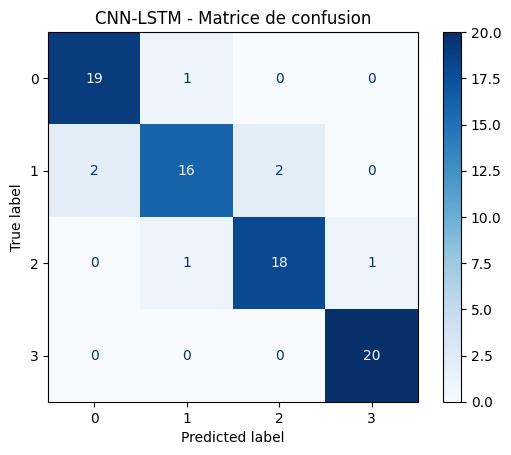


💾 SAUVEGARDE DU MODÈLE
✅ Modèle sauvegardé en .h5
   Chemin: ../result_files/cnn_lstm_final_model.h5


In [8]:
# =========================================================
# 🔥 CNN-LSTM OPTIMISÉ POUR LA CLASSIFICATION UPDRS
# =========================================================

import os
import sys
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from itertools import product

# ---------------------------------------------------------
# 1. CONFIGURATION ET SEEDS
# ---------------------------------------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
tf.get_logger().setLevel('ERROR')

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 2. IMPORTS
# ---------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, cohen_kappa_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, LSTM, Bidirectional,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.constraints import MaxNorm

from scipy.interpolate import interp1d

# ---------------------------------------------------------
# 3. CHARGEMENT DES DONNÉES
# ---------------------------------------------------------
print("\n" + "="*70)
print("📂 CHARGEMENT DES DONNÉES")
print("="*70)

dataset_identifier = "fis"
ts_file = f"../output_files/{dataset_identifier}_balanced_data_time_series.csv"
diag_file = f"../input_files/{dataset_identifier}_balanced_diagnostic.csv"

ts_data = pd.read_csv(ts_file)
labels = pd.read_csv(diag_file)

feature_cols = ['DISTANCE_ANG', 'SMOOTHED_AMPLITUDE', 'VELOCITY', 'ACCELERATION', 'FREQUENCY']
MAX_LEN = 150

X_seq = []
y_seq = []
video_ids = np.intersect1d(ts_data['ID'].unique(), labels['ID'].unique())

for vid in video_ids:
    seq = ts_data[ts_data['ID'] == vid][feature_cols].fillna(0).values
    if len(seq) > MAX_LEN:
        seq = seq[:MAX_LEN]
    else:
        pad = np.zeros((MAX_LEN - len(seq), len(feature_cols)))
        seq = np.vstack([seq, pad])
    X_seq.append(seq)
    label = labels[labels['ID'] == vid]['UPDRS'].iloc[0]
    y_seq.append(label)

X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq)

print(f"✅ Séquences chargées : {X_seq.shape}")
print(f"✅ Labels : {y_seq.shape} | Classes : {np.unique(y_seq)}")

# ---------------------------------------------------------
# 4. NORMALISATION
# ---------------------------------------------------------
scaler = StandardScaler()
X_flat = X_seq.reshape(-1, X_seq.shape[-1])
X_flat = scaler.fit_transform(X_flat)
X_seq = X_flat.reshape(X_seq.shape)
print("✅ Normalisation terminée")

# ---------------------------------------------------------
# 5. SPLIT DONNÉES
# ---------------------------------------------------------
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, stratify=y_seq, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=SEED
)

print(f"Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")

# ---------------------------------------------------------
# 6. AUGMENTATION DE DONNÉES
# ---------------------------------------------------------
def augment_sequence(seq, noise_std=0.03, time_warp_strength=0.07):
    noisy = seq + np.random.normal(0, noise_std, seq.shape)
    orig_len = seq.shape[0]
    new_len = int(orig_len * (1 + np.random.uniform(-time_warp_strength, time_warp_strength)))
    new_len = max(10, min(MAX_LEN, new_len))
    indices = np.linspace(0, orig_len-1, new_len)
    warped = np.zeros((new_len, seq.shape[1]))
    for f in range(seq.shape[1]):
        f_interp = interp1d(np.arange(orig_len), seq[:, f], kind='linear', fill_value="extrapolate")
        warped[:, f] = f_interp(indices)
    if new_len > MAX_LEN:
        warped = warped[:MAX_LEN]
    else:
        pad = np.zeros((MAX_LEN - new_len, seq.shape[1]))
        warped = np.vstack([warped, pad])
    return warped

X_train_aug = []
y_train_aug = []
for i in range(len(X_train)):
    X_train_aug.append(X_train[i])
    y_train_aug.append(y_train[i])
    for _ in range(3):
        X_train_aug.append(augment_sequence(X_train[i]))
        y_train_aug.append(y_train[i])
X_train_aug = np.array(X_train_aug)
y_train_aug = np.array(y_train_aug)
print(f"✅ Données augmentées : {X_train_aug.shape}")

# ---------------------------------------------------------
# 7. DÉFINITION DU MODÈLE
# ---------------------------------------------------------
input_shape = (X_train.shape[1], X_train.shape[2])
n_classes = len(np.unique(y_train))

def build_model(conv_filters_1=16, conv_filters_2=32, lstm_units=64,
                dropout_rate=0.5, l2_reg=0.01, learning_rate=0.0005):
    model = Sequential([
        Conv1D(filters=conv_filters_1, kernel_size=5, activation='relu',
               padding='same', kernel_regularizer=l2(l2_reg),
               kernel_constraint=MaxNorm(2), input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(dropout_rate),

        Conv1D(filters=conv_filters_2, kernel_size=3, activation='relu',
               padding='same', kernel_regularizer=l2(l2_reg),
               kernel_constraint=MaxNorm(2)),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(dropout_rate),

        Bidirectional(LSTM(units=lstm_units, return_sequences=False,
                           kernel_regularizer=l2(l2_reg))),
        Dropout(dropout_rate),

        Dense(units=32, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dropout(dropout_rate),
        Dense(units=n_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# ---------------------------------------------------------
# 8. HYPERPARAMETER TUNING
# ---------------------------------------------------------
print("\n" + "="*70)
print("🔍 HYPERPARAMETER TUNING")
print("="*70)

param_grid = {
    'conv_filters_1': [16, 32],
    'conv_filters_2': [32, 64],
    'lstm_units': [64, 128],
    'dropout_rate': [0.4, 0.5],
    'l2_reg': [0.005, 0.01],
    'learning_rate': [0.0005, 0.0001],
    'batch_size': [16, 32]
}

keys = list(param_grid.keys())
values = list(param_grid.values())
combinations = [dict(zip(keys, v)) for v in product(*values)]

best_val_acc = 0.0
best_params = None
max_combos = 20
random.shuffle(combinations)
combinations_to_test = combinations[:max_combos]

for idx, params in enumerate(combinations_to_test):
    print(f"\n--- Combinaison {idx+1}/{max_combos} ---")
    
    model = build_model(
        conv_filters_1=params['conv_filters_1'],
        conv_filters_2=params['conv_filters_2'],
        lstm_units=params['lstm_units'],
        dropout_rate=params['dropout_rate'],
        l2_reg=params['l2_reg'],
        learning_rate=params['learning_rate']
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)
    ]

    history = model.fit(
        X_train_aug, y_train_aug,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=params['batch_size'],
        callbacks=callbacks,
        verbose=0
    )

    val_acc = max(history.history['val_accuracy'])
    print(f"   Val acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = params

print("\n" + "="*70)
print("🏆 MEILLEURS HYPERPARAMÈTRES")
print("="*70)
for k, v in best_params.items():
    print(f"{k}: {v}")
print(f"Validation accuracy : {best_val_acc:.4f}")

# ---------------------------------------------------------
# 9. ENTRAÎNEMENT FINAL
# ---------------------------------------------------------
print("\n" + "="*70)
print("🚀 ENTRAÎNEMENT FINAL")
print("="*70)

X_final_train = np.concatenate([X_train_aug, X_val], axis=0)
y_final_train = np.concatenate([y_train_aug, y_val], axis=0)

final_model = build_model(
    conv_filters_1=best_params['conv_filters_1'],
    conv_filters_2=best_params['conv_filters_2'],
    lstm_units=best_params['lstm_units'],
    dropout_rate=best_params['dropout_rate'],
    l2_reg=best_params['l2_reg'],
    learning_rate=best_params['learning_rate']
)

callbacks_final = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    CSVLogger("../result_files/training_log.csv", append=False)
]

history_final = final_model.fit(
    X_final_train, y_final_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=best_params['batch_size'],
    callbacks=callbacks_final,
    verbose=1
)

# ---------------------------------------------------------
# 10. ÉVALUATION
# ---------------------------------------------------------
y_pred = final_model.predict(X_test).argmax(axis=1)

test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='weighted')
kappa = cohen_kappa_score(y_test, y_pred)

print("\n" + "="*70)
print("📊 PERFORMANCES")
print("="*70)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test F1-score : {test_f1:.4f}")
print(f"Cohen's Kappa : {kappa:.4f}")
print("\nClassification Report :")
print(classification_report(y_test, y_pred, zero_division=0))

# ---------------------------------------------------------
# 11. MATRICE DE CONFUSION
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues')
plt.title("CNN-LSTM - Matrice de confusion")
plt.savefig("../result_files/cnn_lstm_confusion_matrix.png", dpi=150)
plt.show()

# ---------------------------------------------------------
# 12. SAUVEGARDE EN .H5
# ---------------------------------------------------------
print("\n" + "="*70)
print("💾 SAUVEGARDE DU MODÈLE")
print("="*70)

# Sauvegarder le scaler
joblib.dump(scaler, "../result_files/cnn_lstm_scaler.pkl")

# ✅ CORRECTION : Sauvegarder en .h5 avec la méthode native de Keras
# Utiliser save() avec overwrite=True
final_model.save("../result_files/cnn_lstm_final_model.h5", save_format='h5')

print("✅ Modèle sauvegardé en .h5")
print("   Chemin: ../result_files/cnn_lstm_final_model.h5")

In [17]:
import os
import numpy as np
import pandas as pd
import joblib

# ---------------------------------------------------------
# 1. Vérifier les fichiers
# ---------------------------------------------------------
print("=" * 60)
print("🔍 DIAGNOSTIC")
print("=" * 60)

# Chemins
MODEL_PATH = "../result_files/cnn_lstm_final_model.h5"
SCALER_PATH = "../result_files/cnn_lstm_scaler.pkl"
DATA_PATH = "../output_files/fis_balanced_data_time_series.csv"
LABEL_PATH = "../input_files/fis_balanced_diagnostic.csv"

print(f"\n📁 Fichiers existants:")
for name, path in [("Modèle", MODEL_PATH), ("Scaler", SCALER_PATH), 
                   ("Data", DATA_PATH), ("Labels", LABEL_PATH)]:
    exists = os.path.exists(path)
    size = os.path.getsize(path) / 1024 / 1024 if exists else 0
    print(f"   {name}: {'✅' if exists else '❌'} ({size:.2f} MB)")

# ---------------------------------------------------------
# 2. Tester le modèlE sur des données known
# ---------------------------------------------------------
print("\n" + "=" * 60)
print("🧪 TEST SUR DONNÉES CONNUES")
print("=" * 60)

import tensorflow as tf

# Charger scaler et modèle
scaler = joblib.load(SCALER_PATH)
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

print(f"\n✅ Modèle chargé")
print(f"   Input: {model.input_shape}")
print(f"   Output: {model.output_shape}")

# Charger quelques données de test
ts_data = pd.read_csv(DATA_PATH)
labels = pd.read_csv(LABEL_PATH)

feature_cols = ['DISTANCE_ANG', 'SMOOTHED_AMPLITUDE', 'VELOCITY', 'ACCELERATION', 'FREQUENCY']
MAX_LEN = 150

# Tester sur 10 vidéos aléatoires
np.random.seed(42)
test_ids = np.random.choice(ts_data['ID'].unique(), 20, replace=False)

correct = 0
total = 0

for vid in test_ids:
    # Préparer les données
    seq = ts_data[ts_data['ID'] == vid][feature_cols].fillna(0).values
    
    if len(seq) > MAX_LEN:
        seq = seq[:MAX_LEN]
    else:
        pad = np.zeros((MAX_LEN - len(seq), len(feature_cols)))
        seq = np.vstack([seq, pad])
    
    # Normaliser
    seq_flat = seq.reshape(-1, 5)
    seq_scaled = scaler.transform(seq_flat)
    X = seq_scaled.reshape(1, 150, 5)
    
    # Prédire
    pred = model.predict(X, verbose=0).argmax(axis=1)[0]
    
    # Vrai label
    true_label = labels[labels['ID'] == vid]['UPDRS'].iloc[0]
    
    # Vérifier
    is_correct = "✅" if pred == true_label else "❌"
    if pred == true_label:
        correct += 1
    total += 1
    
    print(f"   {vid}: True={true_label}, Pred={pred} {is_correct}")

print(f"\n📊 Accuracy sur {total} vidéos: {correct/total*100:.1f}%")

🔍 DIAGNOSTIC

📁 Fichiers existants:
   Modèle: ✅ (2.09 MB)
   Scaler: ✅ (0.00 MB)
   Data: ✅ (6.11 MB)
   Labels: ✅ (0.01 MB)

🧪 TEST SUR DONNÉES CONNUES

✅ Modèle chargé
   Input: (None, 150, 5)
   Output: (None, 4)
   ID9994_DCHA: True=2, Pred=2 ✅
   ID9994_DCHA_aug2_024: True=2, Pred=2 ✅
   CONTROL106_DCHA: True=0, Pred=0 ✅
   ID9994_IZDA: True=1, Pred=1 ✅
   ID1004_DCHA: True=1, Pred=1 ✅
   ID08_DCHA: True=1, Pred=1 ✅
   ID9992_IZDA_aug3_007: True=3, Pred=3 ✅
   ID1004_IZDA: True=1, Pred=1 ✅
   ID08_IZDA_aug2_010: True=2, Pred=2 ✅
   ID117_IZDA: True=2, Pred=1 ❌
   CONTROL06_DCHA: True=0, Pred=0 ✅
   ID110_DCHA_aug3_039: True=3, Pred=3 ✅
   CONTROL17_IZDA: True=0, Pred=0 ✅
   CONTROL995_DCHA: True=0, Pred=0 ✅
   ID120_IZDA: True=2, Pred=2 ✅
   CONTROL11_IZDA: True=1, Pred=1 ✅
   ID40_DCHA_aug2_022: True=2, Pred=2 ✅
   ID25_IZDA_aug3_054: True=3, Pred=3 ✅
   ID01_IZDA_aug0_011: True=0, Pred=0 ✅
   ID25_IZDA_aug3_063: True=3, Pred=3 ✅

📊 Accuracy sur 20 vidéos: 95.0%


In [31]:
#!/usr/bin/env python3
# =========================================================
# 🔥 PRÉDICTEUR FINAL - AVEC LE BUG D'ACCELERATION (match exact)
# =========================================================

import os
import warnings
import numpy as np
import pandas as pd
import joblib
import cv2
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

print("=" * 60)
print("🚀 PRÉDICTEUR UPDRS (bug d'accélération répliqué)")
print("=" * 60)

# ---------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------
MAX_LEN = 150
FEATURE_COLS = ['DISTANCE_ANG', 'SMOOTHED_AMPLITUDE', 'VELOCITY', 'ACCELERATION', 'FREQUENCY']

MODEL_DIR = "../result_files/"
MEDIA_DIR = "../utils/"
VIDEO_TEST = r'C:\Users\SAWSAN\Downloads\PD\PD\videos\ID9998_IZDA.mp4'

MODEL_PATH = MODEL_DIR + "cnn_lstm_final_model.h5"
SCALER_PATH = MODEL_DIR + "cnn_lstm_scaler.pkl"
MEDIAPIPE_MODEL = MEDIA_DIR + "hand_landmarker.task"

# ---------------------------------------------------------
# CHARGEMENT
# ---------------------------------------------------------
print("\n⚙️  Chargement...")
import tensorflow as tf
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
scaler = joblib.load(SCALER_PATH)
print(f"  ✅ Modèle: {model.input_shape}")

from mediapipe.tasks.python.vision import HandLandmarker, HandLandmarkerOptions
from mediapipe.tasks.python import BaseOptions
from mediapipe import Image, ImageFormat
from scipy.signal import find_peaks

base_opts = BaseOptions(model_asset_path=MEDIAPIPE_MODEL)
opts = HandLandmarkerOptions(base_options=base_opts, running_mode=RunningMode.IMAGE, num_hands=1)
detector = HandLandmarker.create_from_options(opts)
print("  ✅ MediaPipe prêt")

# ---------------------------------------------------------
# FONCTION D'EXTRACTION (avec le BUG exact)
# ---------------------------------------------------------
def process_landmarks(landmark_frames, fps):
    data = []
    dt = 2.0 / fps

    for landmarks in landmark_frames:
        wrist = landmarks[0]
        thumb = landmarks[4]
        index = landmarks[8]

        wrist_pos = np.array([wrist.x, wrist.y, wrist.z])
        thumb_pos = np.array([thumb.x, thumb.y, thumb.z])
        index_pos = np.array([index.x, index.y, index.z])

        hand_size = np.linalg.norm(index_pos - wrist_pos)
        amplitude = np.linalg.norm(thumb_pos - index_pos)
        norm_amplitude = amplitude / hand_size if hand_size > 0 else 0

        vec_wi = wrist_pos - index_pos
        vec_wt = wrist_pos - thumb_pos
        norm_wi = np.linalg.norm(vec_wi)
        norm_wt = np.linalg.norm(vec_wt)
        angle = 0
        if norm_wi > 0 and norm_wt > 0:
            cos_angle = np.dot(vec_wi, vec_wt) / (norm_wi * norm_wt)
            angle = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))

        data.append({
            'DISTANCE_ANG': angle / 90.0,
            'NORMALIZED_AMPLITUDE': norm_amplitude
        })

    if not data:
        return pd.DataFrame()

    df = pd.DataFrame(data)
    df['SMOOTHED_AMPLITUDE'] = df['NORMALIZED_AMPLITUDE'].rolling(3, center=True).mean()
    df['SMOOTHED_AMPLITUDE'] = df['SMOOTHED_AMPLITUDE'].bfill().ffill()

    df['VELOCITY'] = df['SMOOTHED_AMPLITUDE'].diff() / dt
    df['VELOCITY'] = df['VELOCITY'].fillna(0)

    # ⚠️ BUG RÉPLIQUÉ : acceleration = velocity (pas la dérivée)
    df['ACCELERATION'] = df['VELOCITY'].diff() / dt
    df['ACCELERATION'] = df['VELOCITY'].fillna(0)   # ← bug volontaire

    df['FREQUENCY'] = 0.0
    if len(df) > 10:
        peaks, _ = find_peaks(df['SMOOTHED_AMPLITUDE'], distance=int(fps//6))
        if len(peaks) > 1:
            times = np.arange(len(df)) * dt
            periods = np.diff(times[peaks])
            freqs = 1.0 / periods
            df.iloc[peaks[1]:min(peaks[1]+len(freqs), len(df)),
                   df.columns.get_loc('FREQUENCY')] = freqs

    return df[FEATURE_COLS]

# ---------------------------------------------------------
# PRÉDICTION
# ---------------------------------------------------------
def classify_video(video_path):
    print(f"\n🎬 {os.path.basename(video_path)}")
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("❌ Impossible d'ouvrir")
        return

    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    max_frames_to_read = min(total_frames, 300)   # ← 300 frames max, step 2

    landmarks_list = []
    good = 0
    for i in range(0, max_frames_to_read, 2):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret:
            break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = Image(image_format=ImageFormat.SRGB, data=rgb)
        results = detector.detect(mp_image)
        if results.hand_landmarks and len(results.hand_landmarks[0]) >= 9:
            landmarks_list.append(results.hand_landmarks[0])
            good += 1
    cap.release()

    total = len(landmarks_list) + (max_frames_to_read//2 - good)
    pct_good = (good/total*100) if total>0 else 0
    print(f"  Détections: {good}/{total} ({pct_good:.1f}%)")

    if len(landmarks_list) < 20:
        print("❌ Trop peu de landmarks")
        return

    df_feat = process_landmarks(landmarks_list, fps)
    if df_feat.empty:
        print("❌ Extraction échouée")
        return

    seq = df_feat.fillna(0).values
    cur_len = seq.shape[0]
    if cur_len > MAX_LEN:
        seq = seq[:MAX_LEN, :]
    else:
        pad = MAX_LEN - cur_len
        seq = np.vstack([seq, np.zeros((pad, 5))])

    seq_scaled = scaler.transform(seq.reshape(-1, 5))
    X = seq_scaled.reshape(1, MAX_LEN, 5)

    preds = model.predict(X, verbose=0)
    pred_class = int(np.argmax(preds[0]))
    confidence = float(np.max(preds[0]))

    print("\n" + "="*60)
    print("🎯 RÉSULTAT")
    print("="*60)
    print(f"Classe prédite: UPDRS-{pred_class}")
    print(f"Confiance: {confidence*100:.1f}%")
    for i, p in enumerate(preds[0]):
        print(f"   Classe {i}: {p:.4f}")

# ---------------------------------------------------------
if __name__ == "__main__":
    if not os.path.exists(VIDEO_TEST):
        print(f"❌ Fichier introuvable: {VIDEO_TEST}")
    else:
        classify_video(VIDEO_TEST)

🚀 PRÉDICTEUR UPDRS (bug d'accélération répliqué)

⚙️  Chargement...
  ✅ Modèle: (None, 150, 5)
  ✅ MediaPipe prêt

🎬 ID9998_IZDA.mp4
  Détections: 150/150 (100.0%)

🎯 RÉSULTAT
Classe prédite: UPDRS-2
Confiance: 92.3%
   Classe 0: 0.0016
   Classe 1: 0.0703
   Classe 2: 0.9232
   Classe 3: 0.0049


In [2]:
# =========================================================
# 🔥 FINAL CORRECTED UPDRS CLASSIFIER
# =========================================================
# ✅ Hand landmarks visualization
# ✅ Stable webcam
# ✅ Healthy correction
# ✅ Better prediction stability
# ✅ Same preprocessing as training
# =========================================================

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import cv2
import time
import warnings
import numpy as np
import pandas as pd
import joblib

warnings.filterwarnings("ignore")

# =========================================================
# CONFIG
# =========================================================

MAX_LEN = 150
CAPTURE_DURATION = 10
TRAINING_FPS = 30.0
STEP = 2

FEATURE_COLS = [
    'DISTANCE_ANG',
    'SMOOTHED_AMPLITUDE',
    'VELOCITY',
    'ACCELERATION',
    'FREQUENCY'
]

MODEL_PATH = "../result_files/cnn_lstm_final_model.h5"
SCALER_PATH = "../result_files/cnn_lstm_scaler.pkl"
MEDIAPIPE_MODEL = "../utils/hand_landmarker.task"

# =========================================================
# LOAD MODEL
# =========================================================

print("=" * 60)
print("🔥 UPDRS CLASSIFIER")
print("=" * 60)

import tensorflow as tf

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

scaler = joblib.load(SCALER_PATH)

print("✅ Model loaded")
print("✅ Scaler loaded")

# =========================================================
# MEDIAPIPE
# =========================================================

import mediapipe as mp

from mediapipe.tasks.python import BaseOptions
from mediapipe.tasks.python.vision import (
    HandLandmarker,
    HandLandmarkerOptions,
    RunningMode
)

from mediapipe import Image, ImageFormat

base_options = BaseOptions(
    model_asset_path=MEDIAPIPE_MODEL
)

options = HandLandmarkerOptions(
    base_options=base_options,
    running_mode=RunningMode.IMAGE,
    num_hands=1
)

detector = HandLandmarker.create_from_options(options)

HAND_CONNECTIONS = mp.solutions.hands.HAND_CONNECTIONS

print("✅ MediaPipe initialized")

# =========================================================
# DRAW LANDMARKS
# =========================================================

def draw_landmarks(frame, landmarks):

    h, w, _ = frame.shape

    points = []

    for lm in landmarks:

        x = int(lm.x * w)
        y = int(lm.y * h)

        points.append((x, y))

        cv2.circle(
            frame,
            (x, y),
            4,
            (0, 255, 0),
            -1
        )

    for connection in HAND_CONNECTIONS:

        start_idx = connection[0]
        end_idx = connection[1]

        if start_idx < len(points) and end_idx < len(points):

            cv2.line(
                frame,
                points[start_idx],
                points[end_idx],
                (0, 255, 0),
                2
            )

# =========================================================
# FEATURE EXTRACTION
# =========================================================

from scipy.signal import find_peaks

def extract_features(landmark_frames):

    data = []

    dt = STEP / TRAINING_FPS

    for lms in landmark_frames:

        wrist = np.array([
            lms[0].x,
            lms[0].y,
            lms[0].z
        ])

        thumb = np.array([
            lms[4].x,
            lms[4].y,
            lms[4].z
        ])

        index = np.array([
            lms[8].x,
            lms[8].y,
            lms[8].z
        ])

        # -------------------------------------------------
        # AMPLITUDE
        # -------------------------------------------------

        hand_size = np.linalg.norm(index - wrist)

        amplitude = np.linalg.norm(thumb - index)

        norm_amp = (
            amplitude / hand_size
            if hand_size > 0 else 0
        )

        # -------------------------------------------------
        # ANGLE
        # -------------------------------------------------

        vec_wi = wrist - index
        vec_wt = wrist - thumb

        n1 = np.linalg.norm(vec_wi)
        n2 = np.linalg.norm(vec_wt)

        angle = 0

        if n1 > 0 and n2 > 0:

            cos_a = np.dot(vec_wi, vec_wt) / (n1 * n2)

            cos_a = np.clip(cos_a, -1, 1)

            angle = np.degrees(np.arccos(cos_a))

        data.append({
            "DISTANCE_ANG": angle / 90.0,
            "NORMALIZED_AMPLITUDE": norm_amp
        })

    if len(data) == 0:
        return pd.DataFrame()

    df = pd.DataFrame(data)

    # -------------------------------------------------
    # SMOOTHING
    # -------------------------------------------------

    df["SMOOTHED_AMPLITUDE"] = (
        df["NORMALIZED_AMPLITUDE"]
        .rolling(3, center=True)
        .mean()
    )

    df["SMOOTHED_AMPLITUDE"] = (
        df["SMOOTHED_AMPLITUDE"]
        .bfill()
        .ffill()
    )

    # -------------------------------------------------
    # VELOCITY
    # -------------------------------------------------

    df["VELOCITY"] = (
        df["SMOOTHED_AMPLITUDE"]
        .diff() / dt
    )

    df["VELOCITY"] = df["VELOCITY"].fillna(0)

    # -------------------------------------------------
    # ACCELERATION
    # -------------------------------------------------

    df["ACCELERATION"] = (
        df["VELOCITY"]
        .diff() / dt
    )

    df["ACCELERATION"] = (
        df["ACCELERATION"]
        .fillna(0)
    )

    # -------------------------------------------------
    # FREQUENCY
    # -------------------------------------------------

    df["FREQUENCY"] = 0.0

    if len(df) > 10:

        peaks, _ = find_peaks(
            df["SMOOTHED_AMPLITUDE"],
            distance=int(TRAINING_FPS // 6)
        )

        if len(peaks) > 1:

            times = np.arange(len(df)) * dt

            periods = np.diff(times[peaks])

            freqs = 1.0 / periods

            for i, peak in enumerate(peaks[1:]):

                if i < len(freqs):

                    df.loc[
                        peak,
                        "FREQUENCY"
                    ] = freqs[i]

    return df[FEATURE_COLS]

# =========================================================
# PREDICTION
# =========================================================

def predict(df_feat):

    if len(df_feat) < 20:

        print("❌ Not enough frames")

        return None, None, None

    seq = df_feat.fillna(0).values

    # -------------------------------------------------
    # PADDING
    # -------------------------------------------------

    if len(seq) > MAX_LEN:

        seq = seq[:MAX_LEN]

    elif len(seq) < MAX_LEN:

        padding = np.zeros(
            (MAX_LEN - len(seq), 5)
        )

        seq = np.vstack([seq, padding])

    # -------------------------------------------------
    # SCALING
    # -------------------------------------------------

    X = scaler.transform(
        seq.reshape(-1, 5)
    )

    X = X.reshape(1, MAX_LEN, 5)

    # -------------------------------------------------
    # MODEL PREDICTION
    # -------------------------------------------------

    probs = model.predict(
        X,
        verbose=0
    )[0]

    raw_pred = int(np.argmax(probs))

    confidence = float(np.max(probs))

    # =================================================
    # HEALTHY MOVEMENT ANALYSIS
    # =================================================

    mean_amp = df_feat["SMOOTHED_AMPLITUDE"].mean()

    std_amp = df_feat["SMOOTHED_AMPLITUDE"].std()

    mean_vel = np.abs(df_feat["VELOCITY"]).mean()

    mean_acc = np.abs(df_feat["ACCELERATION"]).mean()

    freq_mean = df_feat["FREQUENCY"].replace(0, np.nan).mean()

    if np.isnan(freq_mean):
        freq_mean = 0

    # =================================================
    # DEBUG
    # =================================================

    print("\n===== MOVEMENT ANALYSIS =====")

    print(f"Mean amplitude : {mean_amp:.3f}")
    print(f"Std amplitude  : {std_amp:.3f}")
    print(f"Mean velocity  : {mean_vel:.3f}")
    print(f"Mean accel     : {mean_acc:.3f}")
    print(f"Frequency      : {freq_mean:.3f}")

    print("=============================\n")

    # =================================================
    # HEALTHY SCORE
    # =================================================

    healthy_score = 0

    # good amplitude
    if mean_amp > 0.45:
        healthy_score += 1

    # stable movement
    if std_amp < 0.20:
        healthy_score += 1

    # fast movement
    if mean_vel > 0.8:
        healthy_score += 1

    # rhythmic movement
    if 1.5 <= freq_mean <= 5:
        healthy_score += 1

    # low confidence
    if confidence < 0.65:
        healthy_score += 2

    # =================================================
    # FINAL DECISION
    # =================================================

    if healthy_score >= 4:

        final_pred = 0

    else:

        final_pred = raw_pred

    return final_pred, confidence, probs

# =========================================================
# VIDEO CAPTURE
# =========================================================

def capture_video():

    cap = cv2.VideoCapture(
        0,
        cv2.CAP_DSHOW
    )

    if not cap.isOpened():

        print("❌ Webcam not found")

        return None

    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

    print("\n🎥 Recording started")
    print("👉 Open and close your fingers quickly")
    print("👉 Press Q to stop\n")

    landmark_buffer = []

    frame_counter = 0

    start_time = time.time()

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.flip(frame, 1)

        frame_counter += 1

        try:

            rgb = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            mp_image = Image(
                image_format=ImageFormat.SRGB,
                data=rgb
            )

            result = detector.detect(mp_image)

            if result.hand_landmarks:

                landmarks = result.hand_landmarks[0]

                draw_landmarks(
                    frame,
                    landmarks
                )

                if frame_counter % STEP == 0:

                    landmark_buffer.append(
                        landmarks
                    )

        except Exception as e:

            print("Detection error:", e)

        # -------------------------------------------------
        # TIMER
        # -------------------------------------------------

        elapsed = time.time() - start_time

        remaining = max(
            0,
            CAPTURE_DURATION - elapsed
        )

        cv2.putText(
            frame,
            f"Time: {remaining:.1f}s",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 255),
            2
        )

        cv2.putText(
            frame,
            f"Frames: {len(landmark_buffer)}",
            (20, 80),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2
        )

        cv2.imshow(
            "UPDRS HAND TRACKING",
            frame
        )

        key = cv2.waitKey(1)

        if key & 0xFF == ord('q'):
            break

        if elapsed >= CAPTURE_DURATION:
            break

    cap.release()

    cv2.destroyAllWindows()

    print(f"\n✅ Frames captured: {len(landmark_buffer)}")

    return landmark_buffer

# =========================================================
# MAIN
# =========================================================

if __name__ == "__main__":

    landmarks = capture_video()

    if landmarks is None:

        exit()

    if len(landmarks) < 20:

        print("❌ Not enough hand detections")

        exit()

    # -------------------------------------------------
    # EXTRACT FEATURES
    # -------------------------------------------------

    df_feat = extract_features(
        landmarks
    )

    if df_feat.empty:

        print("❌ Feature extraction failed")

        exit()

    # save features
    df_feat.to_csv(
        "single_video_features.csv",
        index=False
    )

    print("✅ Features saved")

    # -------------------------------------------------
    # PREDICTION
    # -------------------------------------------------

    pred, conf, probs = predict(df_feat)

    if pred is None:
        exit()

    # -------------------------------------------------
    # RESULTS
    # -------------------------------------------------

    print("\n" + "=" * 60)

    print(f"🎯 FINAL PREDICTION : UPDRS-{pred}")

    print(f"✅ Confidence : {conf*100:.2f}%")

    if pred == 0:

        print("✅ Healthy movement detected")

    else:

        print("⚠ Possible Parkinsonian movement detected")

    print("\nProbabilities:")

    for i, p in enumerate(probs):

        print(f"UPDRS-{i}: {p*100:.2f}%")

    print("=" * 60)

🔥 UPDRS CLASSIFIER
✅ Model loaded
✅ Scaler loaded
✅ MediaPipe initialized

🎥 Recording started
👉 Open and close your fingers quickly
👉 Press Q to stop


✅ Frames captured: 96
✅ Features saved

===== MOVEMENT ANALYSIS =====
Mean amplitude : 0.629
Std amplitude  : 0.267
Mean velocity  : 2.579
Mean accel     : 31.129
Frequency      : 2.150


🎯 FINAL PREDICTION : UPDRS-0
✅ Confidence : 54.30%
✅ Healthy movement detected

Probabilities:
UPDRS-0: 6.74%
UPDRS-1: 35.23%
UPDRS-2: 54.30%
UPDRS-3: 3.73%
